<a href="https://colab.research.google.com/github/mebre7/house-price-predictor-mlops/blob/colab_branch/notebooks/02_feature_engineering_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering and Model Training
Feature engineering is the process of using domain knowledge to create new features from existing data. It involves transforming raw data into a format that is more suitable for machine learning algorithms, which can lead to improved model performance.
- In this notebook of the house price predictor project, I will be performing feature engineering on the dataset to create new features that can help improve the predictive power of the model. This may include creating interaction terms, polynomial features, or aggregating existing features to capture more complex relationships in the data.

##1. Import Packages & Environment Setup

In [ ]:
%pip install catboost
%pip install xgboost
%pip install lightgbm

In [164]:
import os
import sys
import pickle
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from urllib.parse import quote_plus
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
from google.colab import userdata

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor, GradientBoostingRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

##2. Data Ingestion

In [165]:
# 1. Load credentials from google colab credentials

DB_USER = userdata.get("SUPABASE_USER")
DB_PASSWORD = quote_plus(userdata.get("SUPABASE_PASSWORD"))
DB_HOST = userdata.get("SUPABASE_HOST")
DB_PORT = userdata.get("SUPABASE_PORT")
DB_NAME = userdata.get("SUPABASE_NAME")

DATABASE_URL = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

try:
    engine = create_engine(DATABASE_URL)
    with engine.connect() as conn:
        df = pd.read_sql(text("SELECT * FROM housing_data"), conn)
    print("Data loaded successfully from Supabase PostgreSQL database.")
except Exception as e:
    print(f"PostgreSQL connection failed ({e}). Loading from raw CSV fallback...")
    raw_path = os.path.join("..", "data", "raw", "AmesHousing.csv")
    if not os.path.exists(raw_path):
        raw_path = os.path.join("data", "raw", "AmesHousing.csv")
    df = pd.read_csv(raw_path)
    print(f"Data loaded successfully from local CSV: {raw_path}")

# Drop PID / Order columns
drop_cols = [c for c in ["Order", "PID", "Id"] if c in df.columns]
if drop_cols:
    df = df.drop(columns=drop_cols)

print(f"Dataset Shape: {df.shape}")
df.head()

Data loaded successfully from Supabase PostgreSQL database.
Dataset Shape: (2930, 80)


,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition,SalePrice
0,20,RL,141.0,31770,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,None,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,MnPrv,None,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,None,Reg,Lvl,AllPub,Corner,...,0,None,None,None,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,None,IR1,Lvl,AllPub,Inside,...,0,None,MnPrv,None,0,3,2010,WD,Normal,189900


In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS_SubClass      2930 non-null   int64  
 1   MS_Zoning        2930 non-null   object 
 2   Lot_Frontage     2440 non-null   float64
 3   Lot_Area         2930 non-null   int64  
 4   Street           2930 non-null   object 
 5   Alley            198 non-null    object 
 6   Lot_Shape        2930 non-null   object 
 7   Land_Contour     2930 non-null   object 
 8   Utilities        2930 non-null   object 
 9   Lot_Config       2930 non-null   object 
 10  Land_Slope       2930 non-null   object 
 11  Neighborhood     2930 non-null   object 
 12  Condition_1      2930 non-null   object 
 13  Condition_2      2930 non-null   object 
 14  Bldg_Type        2930 non-null   object 
 15  House_Style      2930 non-null   object 
 16  Overall_Qual     2930 non-null   int64  
 17  Overall_Cond  

##2. Features classification

**1. Numerical features**

In [167]:
# define numerical features
numerical_features_all = df.select_dtypes(include=[np.number]).columns.tolist()

In [168]:
len(numerical_features_all)

37

In [169]:
len(df.select_dtypes(include=["float64", "int64"]).columns.to_list())

37

In [170]:
# Discrete numerical features
discrete_num_features = [
    'Bsmt_Full_Bath',
    'Bsmt_Half_Bath',
    'Full_Bath',
    'Half_Bath',
    'Bedroom_AbvGr',
    'Kitchen_AbvGr',
    'TotRms_AbvGrd',
    'Fireplaces',
    'Garage_Cars'
]

In [171]:
# Continuous numerical features
continuous_num_features = [
    'Lot_Frontage',
    'Lot_Area',
    'Mas_Vnr_Area',
    'BsmtFin_SF_1',
    'BsmtFin_SF_2',
    'Bsmt_Unf_SF',
    'Total_Bsmt_SF',
    '1st_Flr_SF',
    '2nd_Flr_SF',
    'Low_Qual_Fin_SF',
    'Gr_Liv_Area',
    'Garage_Area',
    'Wood_Deck_SF',
    'Open_Porch_SF',
    'Enclosed_Porch',
    '3Ssn_Porch',
    'Screen_Porch',
    'Pool_Area',
    'Misc_Val'
]

In [172]:
num_features_only = discrete_num_features + continuous_num_features
print(f'{len(num_features_only)} numerical features')

28 numerical features


**2. Categorical features**

In [173]:
# Nominal categorical features
nominal_cat_features = [
    'MS_SubClass',
    'MS_Zoning',
    'Street',
    'Alley',
    'Land_Contour',
    'Utilities',
    'Lot_Config',
    'Neighborhood',
    'Condition_1',
    'Condition_2',
    'Bldg_Type',
    'House_Style',
    'Roof_Style',
    'Roof_Matl',
    'Exterior_1st',
    'Exterior_2nd',
    'Mas_Vnr_Type',
    'Foundation',
    'Heating',
    'Central_Air',
    'Electrical',
    'Garage_Type',
    'Paved_Drive',
    'Fence',
    'Misc_Feature',
    'Sale_Type',
    'Sale_Condition'
]

In [174]:
# Ordinal categorical features
ordinal_cat_features = [
    'Lot_Shape',
    'Land_Slope',
    'Overall_Qual',
    'Overall_Cond',
    'Exter_Qual',
    'Exter_Cond',
    'Bsmt_Qual',
    'Bsmt_Cond',
    'Bsmt_Exposure',
    'BsmtFin_Type_1',
    'BsmtFin_Type_2',
    'Heating_QC',
    'Kitchen_Qual',
    'Functional',
    'Fireplace_Qu',
    'Garage_Finish',
    'Garage_Qual',
    'Garage_Cond',
    'Pool_QC'
]

In [175]:
categorical_features = nominal_cat_features + ordinal_cat_features
print(f'{len(categorical_features)} categorical featurese')

46 categorical featurese


In [176]:
set(categorical_features).intersection(set(discrete_num_features))

set()

**Change data types of `categorical_features` to `category` for memory efficiency and better performance in modeling.**

In [177]:
for col in categorical_features:
    df[col] = df[col].astype('category')

In [178]:
df[categorical_features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 46 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   MS_SubClass     2930 non-null   category
 1   MS_Zoning       2930 non-null   category
 2   Street          2930 non-null   category
 3   Alley           198 non-null    category
 4   Land_Contour    2930 non-null   category
 5   Utilities       2930 non-null   category
 6   Lot_Config      2930 non-null   category
 7   Neighborhood    2930 non-null   category
 8   Condition_1     2930 non-null   category
 9   Condition_2     2930 non-null   category
 10  Bldg_Type       2930 non-null   category
 11  House_Style     2930 non-null   category
 12  Roof_Style      2930 non-null   category
 13  Roof_Matl       2930 non-null   category
 14  Exterior_1st    2930 non-null   category
 15  Exterior_2nd    2930 non-null   category
 16  Mas_Vnr_Type    1155 non-null   category
 17  Foundation    

**3. Temporal features**

In [179]:
date_year = ['Year_Built', 'Year_Remod/Add', 'Garage_Yr_Blt', 'Yr_Sold', ]
date_month = ['Mo_Sold']

for col in date_year:
    df[col] = pd.to_datetime(df[col], format='%Y').dt.year

for col in date_month:
    df[col] = pd.to_datetime(df[col], format='%m').dt.month

In [180]:
# Temporal features
temporal_features = date_year + date_month
temporal_features

['Year_Built', 'Year_Remod/Add', 'Garage_Yr_Blt', 'Yr_Sold', 'Mo_Sold']

**4. Target feature**

In [181]:
target = ['SalePrice']

**All features**

In [182]:
all_features = discrete_num_features + continuous_num_features + nominal_cat_features + ordinal_cat_features + temporal_features + target

In [183]:
len(all_features)

80

In [184]:
len(df.columns.to_list())

80

**Summarize**

In [185]:
print(len(discrete_num_features))
print(len(continuous_num_features))
print(len(nominal_cat_features))
print(len(ordinal_cat_features))
print(len(temporal_features))
print(len(target))

9
19
27
19
5
1


**Total features = 80**
- **Total numerical features = $37$ ($11$ discrete, $19$ continuous, $5$ temporal, $1$ target, $1$ categorical)**
- discrete numerical features = $9$
- continuous features = $37 - 11 - 5 - 1 - 1 = 19$
- temporal features = $5$
- target feature = $1$
- **total categorical features = $46$ ($2$ from discrete)**
- ordinal categorical features = $19$
- nominal categorial features = $27$

-> **Total features $= 9 + 19 + 5 + 1 + 19 + 27=80$**

In [186]:

# print columns
print(f'{len(discrete_num_features)} discrete numerical features: {discrete_num_features}')
print(f'\n{len(continuous_num_features)} continuous numerical features: {continuous_num_features}')
print(f'\n{len(ordinal_cat_features)} ordinal categorical features: {ordinal_cat_features}')
print(f'\n{len(nominal_cat_features)} nominal categorical features: {nominal_cat_features}')
print(f'\n{len(temporal_features)} temporal features: {temporal_features}')
print(f'\n{len(target)} target feature: {target}')

9 discrete numerical features: ['Bsmt_Full_Bath', 'Bsmt_Half_Bath', 'Full_Bath', 'Half_Bath', 'Bedroom_AbvGr', 'Kitchen_AbvGr', 'TotRms_AbvGrd', 'Fireplaces', 'Garage_Cars']

19 continuous numerical features: ['Lot_Frontage', 'Lot_Area', 'Mas_Vnr_Area', 'BsmtFin_SF_1', 'BsmtFin_SF_2', 'Bsmt_Unf_SF', 'Total_Bsmt_SF', '1st_Flr_SF', '2nd_Flr_SF', 'Low_Qual_Fin_SF', 'Gr_Liv_Area', 'Garage_Area', 'Wood_Deck_SF', 'Open_Porch_SF', 'Enclosed_Porch', '3Ssn_Porch', 'Screen_Porch', 'Pool_Area', 'Misc_Val']

19 ordinal categorical features: ['Lot_Shape', 'Land_Slope', 'Overall_Qual', 'Overall_Cond', 'Exter_Qual', 'Exter_Cond', 'Bsmt_Qual', 'Bsmt_Cond', 'Bsmt_Exposure', 'BsmtFin_Type_1', 'BsmtFin_Type_2', 'Heating_QC', 'Kitchen_Qual', 'Functional', 'Fireplace_Qu', 'Garage_Finish', 'Garage_Qual', 'Garage_Cond', 'Pool_QC']

27 nominal categorical features: ['MS_SubClass', 'MS_Zoning', 'Street', 'Alley', 'Land_Contour', 'Utilities', 'Lot_Config', 'Neighborhood', 'Condition_1', 'Condition_2', 'Bldg_Typ

In [187]:
# total
print(f'Numer of all features: {len(discrete_num_features) + len(continuous_num_features) + len(ordinal_cat_features) + len(nominal_cat_features) + len(temporal_features) + len(target)}')

Numer of all features: 80


## 4. Train-Test split

In [188]:
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [189]:
X_train.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Screen_Porch,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition
381,20,RL,80.0,10400,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,6,2009,WD,Family
834,60,RL,NaN,28698,Pave,NaN,IR2,Low,AllPub,CulDSac,...,225,0,NaN,NaN,NaN,0,6,2009,WD,Abnorml
1898,20,RL,75.0,7388,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,7,2007,WD,Normal
678,90,RL,60.0,8544,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,6,2009,WD,Normal
700,70,RM,57.0,6406,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,182,0,NaN,MnPrv,NaN,0,10,2009,WD,Normal


In [190]:
X_test.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Screen_Porch,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition
1357,50,RL,60.0,9144,Pave,Pave,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,3,2008,WD,Normal
2367,160,RM,21.0,1953,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
2822,20,RL,73.0,16133,Pave,NaN,Reg,HLS,AllPub,Inside,...,112,0,NaN,NaN,NaN,0,12,2006,WD,Abnorml
2126,20,RL,70.0,16561,Pave,NaN,IR2,Low,AllPub,Inside,...,0,0,NaN,GdPrv,NaN,0,7,2007,WD,Normal
1544,160,RM,24.0,1950,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,GdPrv,NaN,0,7,2008,COD,Normal


In [191]:
y_train.head()

,SalePrice
381,152000
834,185000
1898,150750
678,92900
700,150000


In [192]:
y_test.head()

,SalePrice
1357,162500
2367,83000
2822,119900
2126,147900
1544,151000


## 5. Missing Value Handling (Imputation)

In [193]:
count = X.isnull().sum().sort_values(ascending=False)
percentage = ((X.isnull().sum() / df.isnull().count()) * 100).sort_values(ascending=False)
null_values = pd.concat([count, percentage], axis=1, keys=['Count', 'Percentage'])

In [194]:
null_values.head()

,Count,Percentage
Pool_QC,2917.0,99.556314
Misc_Feature,2824.0,96.382253
Alley,2732.0,93.242321
Fence,2358.0,80.477816
Mas_Vnr_Type,1775.0,60.580205


**Visualize missing values**

In [195]:
fig = px.bar(x=null_values.index, y=null_values['Percentage'],
             labels={'x': 'Features', 'y': 'Percent of missing values'},
             title='Percent missing data by feature')
fig.update_layout(xaxis_tickangle=-45)
fig.show()

**1. Structural Absence (Replace `NaN` with `None` or `0`)**

These columns use missing values to denote that the feature does not exist on the property.

- **`structural_categorical` (Fill with `None`)**

In [196]:
structural_categorical = [
    'Alley',

    'Bsmt_Qual',
    'Bsmt_Cond',
    'Bsmt_Exposure',
    'BsmtFin_Type_1',
    'BsmtFin_Type_2',

    'Fireplace_Qu',

    'Garage_Type',
    'Garage_Finish',
    'Garage_Qual',
    'Garage_Cond',

    'Pool_QC',
    'Fence',
    'Misc_Feature'
]

```
df.Alley=["No Alley" if x is np.nan else x for x in df.Alley]
df.Mas_Vnr_Type=["Missing" if x is np.nan else x for x in df.Mas_Vnr_Type]
df.Bsmt_Qual=["No Bsmnt" if x is np.nan else x for x in df.Bsmt_Qual]
df.Bsmt_Cond=["No Bsmnt" if x is np.nan else x for x in df.Bsmt_Cond]
df.Bsmt_Exposure=["No Bsmnt" if x is np.nan else x for x in df.Bsmt_Exposure]
df.BsmtFin_Type_1=["No Bsmnt" if x is np.nan else x for x in df.BsmtFin_Type_1]
df.BsmtFin_Type_2=["No Bsmnt" if x is np.nan else x for x in df.BsmtFin_Type_2]
df.Fireplace_Qu=["No Firepl" if x is np.nan else x for x in df.Fireplace_Qu]
df.Garage_Type=["No Grg" if x is np.nan else x for x in df.Garage_Type]
df.Garage_Finish=["No Grg" if x is np.nan else x for x in df.Garage_Finish]
df.Garage_Qual=["No Grg" if x is np.nan else x for x in df.Garage_Qual]
df.Garage_Cond=["No Grg" if x is np.nan else x for x in df.Garage_Cond]
df.Pool_QC=["No Pool" if x is np.nan else x for x in df.Pool_QC]
df.Fence=["No Fence" if x is np.nan else x for x in df.Fence]
df.Misc_Feature=["None" if x is np.nan else x for x in df.Misc_Feature]
```

```py
df['Alley'] = df['Alley'].fillna('No Alley')
df['Mas_Vnr_Type'] = df['Mas_Vnr_Type'].fillna('Missing')
df['Bsmt_Qual'] = df['Bsmt_Qual'].fillna('No Bsmnt')
df['Bsmt_Cond'] = df['Bsmt_Cond'].fillna('No Bsmnt')
df['Bsmt_Exposure'] = df['Bsmt_Exposure'].fillna('No Bsmnt')
df['BsmtFin_Type_1'] = df['BsmtFin_Type_1'].fillna('No Bsmnt')
df['BsmtFin_Type_2'] = df['BsmtFin_Type_2'].fillna('No Bsmnt')
df['Fireplace_Qu'] = df['Fireplace_Qu'].fillna('No Firepl')
df['Garage_Type'] = df['Garage_Type'].fillna('No Grg')
df['Garage_Finish'] = df['Garage_Finish'].fillna('No Grg')
df['Garage_Qual'] = df['Garage_Qual'].fillna('No Grg')
df['Garage_Cond'] = df['Garage_Cond'].fillna('No Grg')
df['Pool_QC'] = df['Pool_QC'].fillna('No Pool')
df['Fence'] = df['Fence'].fillna('No Fence')
df['Misc_Feature'] = df['Misc_Feature'].fillna('None')
```

In [197]:
fill_values = {
    'Alley': 'No Alley Access',
    'Bsmt_Qual': 'No Basement',
    'Bsmt_Cond': 'No Basement',
    'Bsmt_Exposure': 'No Basement',
    'BsmtFin_Type_1': 'No Basement',
    'BsmtFin_Type_2': 'No Basement',
    'Fireplace_Qu': 'No Fireplace',
    'Garage_Type': 'No Garage',
    'Garage_Finish': 'No Garage',
    'Garage_Qual': 'No Garage',
    'Garage_Cond': 'No Garage',
    'Pool_QC': 'No Pool',
    'Fence': 'No Fence',
    'Misc_Feature': 'None'
}
for col, fill_value in fill_values.items():
    if fill_value not in X[col].cat.categories:
        X[col] = X[col].cat.add_categories(fill_value)
    X[col] = X[col].fillna(fill_value)

In [198]:
X[structural_categorical].isnull().sum()

,0
Alley,0
Bsmt_Qual,0
Bsmt_Cond,0
Bsmt_Exposure,0
BsmtFin_Type_1,0
BsmtFin_Type_2,0
Fireplace_Qu,0
Garage_Type,0
Garage_Finish,0
Garage_Qual,0


- **`structural_numerical` (Fill with `0`)**

In [199]:
structural_numerical = [
    'BsmtFin_SF_1', 'BsmtFin_SF_2', 'Bsmt_Unf_SF', 'Total_Bsmt_SF',
    'Bsmt_Full_Bath', 'Bsmt_Half_Bath', 'Garage_Cars', 'Garage_Area', 'Mas_Vnr_Area'
]

In [200]:
for col in structural_numerical:
  X[col] = X[col].fillna(0)

In [201]:
X[structural_numerical].isnull().sum()

,0
BsmtFin_SF_1,0
BsmtFin_SF_2,0
Bsmt_Unf_SF,0
Total_Bsmt_SF,0
Bsmt_Full_Bath,0
Bsmt_Half_Bath,0
Garage_Cars,0
Garage_Area,0
Mas_Vnr_Area,0


**Checking**

In [202]:
X[structural_numerical + structural_categorical].isnull().sum().sum()

np.int64(0)

In [203]:
len(structural_numerical + structural_categorical)

23

In [204]:
X[structural_categorical + structural_numerical].head()

,Alley,Bsmt_Qual,Bsmt_Cond,Bsmt_Exposure,BsmtFin_Type_1,BsmtFin_Type_2,Fireplace_Qu,Garage_Type,Garage_Finish,Garage_Qual,...,Misc_Feature,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,Bsmt_Full_Bath,Bsmt_Half_Bath,Garage_Cars,Garage_Area,Mas_Vnr_Area
0,No Alley Access,TA,Gd,Gd,BLQ,Unf,Gd,Attchd,Fin,TA,...,None,639.0,0.0,441.0,1080.0,1.0,0.0,2.0,528.0,112.0
1,No Alley Access,TA,TA,No,Rec,LwQ,No Fireplace,Attchd,Unf,TA,...,None,468.0,144.0,270.0,882.0,0.0,0.0,1.0,730.0,0.0
2,No Alley Access,TA,TA,No,ALQ,Unf,No Fireplace,Attchd,Unf,TA,...,Gar2,923.0,0.0,406.0,1329.0,0.0,0.0,1.0,312.0,108.0
3,No Alley Access,TA,TA,No,ALQ,Unf,TA,Attchd,Fin,TA,...,None,1065.0,0.0,1045.0,2110.0,1.0,0.0,2.0,522.0,0.0
4,No Alley Access,Gd,TA,No,GLQ,Unf,TA,Attchd,Fin,TA,...,None,791.0,0.0,137.0,928.0,0.0,0.0,2.0,482.0,0.0


In [205]:
features_with_missing_values = list(set(X.columns.to_list()) - set(structural_numerical + structural_categorical))
print(len(features_with_missing_values))
features_with_missing_values

56


['Exter_Qual',
 'Utilities',
 'TotRms_AbvGrd',
 'Year_Built',
 'Roof_Style',
 'Wood_Deck_SF',
 'Open_Porch_SF',
 'Electrical',
 'Roof_Matl',
 'Exterior_1st',
 'Exter_Cond',
 'Gr_Liv_Area',
 'Foundation',
 'Central_Air',
 'Overall_Cond',
 'Neighborhood',
 'Low_Qual_Fin_SF',
 'Bldg_Type',
 'Year_Remod/Add',
 'Garage_Yr_Blt',
 'Exterior_2nd',
 'Kitchen_AbvGr',
 'Paved_Drive',
 'Screen_Porch',
 'Mo_Sold',
 'Condition_1',
 'Heating',
 'Lot_Area',
 'Heating_QC',
 '3Ssn_Porch',
 'Kitchen_Qual',
 'Sale_Condition',
 'House_Style',
 'MS_Zoning',
 'Sale_Type',
 'Condition_2',
 'Enclosed_Porch',
 '2nd_Flr_SF',
 'Misc_Val',
 'Lot_Config',
 '1st_Flr_SF',
 'Land_Contour',
 'Mas_Vnr_Type',
 'Street',
 'Lot_Shape',
 'Lot_Frontage',
 'Overall_Qual',
 'Pool_Area',
 'Yr_Sold',
 'Bedroom_AbvGr',
 'Fireplaces',
 'Land_Slope',
 'MS_SubClass',
 'Full_Bath',
 'Functional',
 'Half_Bath']

> Out of $80$ total features, $22$ features with missing values are handled considering _structuring absence_. Remaining $58$ will be handled by _statistical imputation_ and other ways.

In [206]:
X.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Screen_Porch,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition
0,20,RL,141.0,31770,Pave,No Alley Access,IR1,Lvl,AllPub,Corner,...,0,0,No Pool,No Fence,None,0,5,2010,WD,Normal
1,20,RH,80.0,11622,Pave,No Alley Access,Reg,Lvl,AllPub,Inside,...,120,0,No Pool,MnPrv,None,0,6,2010,WD,Normal
2,20,RL,81.0,14267,Pave,No Alley Access,IR1,Lvl,AllPub,Corner,...,0,0,No Pool,No Fence,Gar2,12500,6,2010,WD,Normal
3,20,RL,93.0,11160,Pave,No Alley Access,Reg,Lvl,AllPub,Corner,...,0,0,No Pool,No Fence,None,0,4,2010,WD,Normal
4,60,RL,74.0,13830,Pave,No Alley Access,IR1,Lvl,AllPub,Inside,...,0,0,No Pool,MnPrv,None,0,3,2010,WD,Normal


In [207]:
# updated X_train and X_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**2. Statistical Imputation (True Missingness/Clerical Errors)**

These features are physically required for a house to exist. Missing data here represents a processing omission or clerical typo.

- **`spatial_numerical` (Impute using the median of their specific `Neighborhood`)**

In [208]:
spatial_numerical = ['Lot_Frontage']

In [209]:
X_train[spatial_numerical].isnull().sum()

,0
Lot_Frontage,396


In [210]:
X_test[spatial_numerical].isnull().sum()

,0
Lot_Frontage,94


In [211]:
X[spatial_numerical].isnull().sum()

,0
Lot_Frontage,490


In [212]:
# Calculate the median Lot_Frontage per Neighborhood from X_train
neighborhood_medians = X_train.groupby('Neighborhood')['Lot_Frontage'].median()

In [213]:
# fill missing values in X_train using the training medians
X_train['Lot_Frontage'] = X_train['Lot_Frontage'].fillna(X_train['Neighborhood']).map(neighborhood_medians)

In [214]:
# Fill missing values in X_test using the *exact same* training medians
X_test['Lot_Frontage'] = X_test['Lot_Frontage'].fillna(X_test['Neighborhood'].map(neighborhood_medians))

In [215]:
# Fallback: If a neighborhood in X_test happens to have all NaNs or a new category
# not seen in training, fill remaining NaNs with the overall X_train median
global_median = X_train['Lot_Frontage'].median()
X_train['Lot_Frontage'] = X_train['Lot_Frontage'].fillna(global_median)
X_test['Lot_Frontage'] = X_test['Lot_Frontage'].fillna(global_median)

In [216]:
X_train[spatial_numerical].isnull().sum()

,0
Lot_Frontage,0


In [217]:
X_test[spatial_numerical].isnull().sum()

,0
Lot_Frontage,0


In [218]:
# update whole dataset
X = pd.concat([X_train, X_test], axis=0)

In [219]:
X.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Screen_Porch,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition
381,20,RL,72.0,10400,Pave,No Alley Access,Reg,Lvl,AllPub,Inside,...,0,0,No Pool,MnPrv,None,0,6,2009,WD,Family
834,60,RL,80.0,28698,Pave,No Alley Access,IR2,Low,AllPub,CulDSac,...,225,0,No Pool,No Fence,None,0,6,2009,WD,Abnorml
1898,20,RL,72.0,7388,Pave,No Alley Access,Reg,Lvl,AllPub,Corner,...,0,0,No Pool,No Fence,None,0,7,2007,WD,Normal
678,90,RL,72.0,8544,Pave,No Alley Access,Reg,Lvl,AllPub,Corner,...,0,0,No Pool,No Fence,None,0,6,2009,WD,Normal
700,70,RM,72.0,6406,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,182,0,No Pool,MnPrv,None,0,10,2009,WD,Normal


- **`mode_categorical` (Impute using the column's global mode/most frequent item)**

In [220]:
mode_categorical = [
    'Utilities', 'Exterior_1st', 'Exterior_2nd', 'Electrical',
    'Kitchen_Qual', 'Functional', 'Sale_Type'
]

In [221]:
X[mode_categorical].isnull().sum()

,0
Utilities,0
Exterior_1st,0
Exterior_2nd,0
Electrical,1
Kitchen_Qual,0
Functional,0
Sale_Type,0


In [222]:
X[mode_categorical].head()

,Utilities,Exterior_1st,Exterior_2nd,Electrical,Kitchen_Qual,Functional,Sale_Type
381,AllPub,HdBoard,HdBoard,SBrkr,TA,Typ,WD
834,AllPub,Plywood,Plywood,SBrkr,TA,Min2,WD
1898,AllPub,MetalSd,MetalSd,SBrkr,Gd,Typ,WD
678,AllPub,BrkFace,BrkFace,FuseA,TA,Typ,WD
700,AllPub,Wd Sdng,Wd Sdng,FuseA,TA,Typ,WD


In [223]:
for col in mode_categorical:
    if df[col].isnull().sum() > 0:
        X[col] = X[col].fillna(X[col].mode()[0])

- **`special_case_temporal` (Impute missing indices dynamically with that row's `Year_Built` value)**

In [224]:
special_case_temporal = ['Garage_Yr_Blt']

In [225]:
X[temporal_features].isnull().sum()

,0
Year_Built,0
Year_Remod/Add,0
Garage_Yr_Blt,159
Yr_Sold,0
Mo_Sold,0


In [226]:
X[temporal_features].head()

,Year_Built,Year_Remod/Add,Garage_Yr_Blt,Yr_Sold,Mo_Sold
381,1976,1976,1976.0,2009,6
834,1967,1967,1967.0,2009,6
1898,1959,2002,1974.0,2007,7
678,1950,1950,1987.0,2009,6
700,1939,1950,1939.0,2009,10


In [227]:
X['Garage_Yr_Blt'] = X['Garage_Yr_Blt'].fillna(X['Year_Built'])

In [228]:
X[temporal_features].isnull().sum()

,0
Year_Built,0
Year_Remod/Add,0
Garage_Yr_Blt,0
Yr_Sold,0
Mo_Sold,0


The data dictionary describes `MasVnrType` as masonry veneer type and `MasVnrArea` as veneer area.

In [229]:
X[['Mas_Vnr_Area', 'Mas_Vnr_Area']].isnull().sum()

,0
Mas_Vnr_Area,0
Mas_Vnr_Area,0


In [230]:
X.loc[
    X["Mas_Vnr_Type"].eq("None") &
    X["Mas_Vnr_Area"].isna(),
    "Mas_Vnr_Area"
] = 0

# Correcting the imputation for Mas_Vnr_Type
# It was previously handled in the code block PIIK1l3yFmJ6 (markdown)
# We ensure 'Missing' is a category and fill NaNs with it.
if 'Missing' not in X['Mas_Vnr_Type'].cat.categories:
    X['Mas_Vnr_Type'] = X['Mas_Vnr_Type'].cat.add_categories('Missing')
X['Mas_Vnr_Type'] = X['Mas_Vnr_Type'].fillna('Missing')


**Final check for existence of null values**

In [231]:
# Null values left?
print(X.isnull().values.any())
if X.isnull().values.any():
  print("Yes, there exist null values!")
  null_counts = X.isnull().sum()
  null_counts = null_counts[null_counts > 0]
  print(null_counts)
else:
  print("No null values")

False
No null values


> **Final dataset with no missing values**

In [232]:
# updated X_train and X_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [233]:
X.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Screen_Porch,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition
381,20,RL,72.0,10400,Pave,No Alley Access,Reg,Lvl,AllPub,Inside,...,0,0,No Pool,MnPrv,None,0,6,2009,WD,Family
834,60,RL,80.0,28698,Pave,No Alley Access,IR2,Low,AllPub,CulDSac,...,225,0,No Pool,No Fence,None,0,6,2009,WD,Abnorml
1898,20,RL,72.0,7388,Pave,No Alley Access,Reg,Lvl,AllPub,Corner,...,0,0,No Pool,No Fence,None,0,7,2007,WD,Normal
678,90,RL,72.0,8544,Pave,No Alley Access,Reg,Lvl,AllPub,Corner,...,0,0,No Pool,No Fence,None,0,6,2009,WD,Normal
700,70,RM,72.0,6406,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,182,0,No Pool,MnPrv,None,0,10,2009,WD,Normal


In [234]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2930 entries, 381 to 1488
Data columns (total 79 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   MS_SubClass      2930 non-null   category
 1   MS_Zoning        2930 non-null   category
 2   Lot_Frontage     2930 non-null   float64 
 3   Lot_Area         2930 non-null   int64   
 4   Street           2930 non-null   category
 5   Alley            2930 non-null   category
 6   Lot_Shape        2930 non-null   category
 7   Land_Contour     2930 non-null   category
 8   Utilities        2930 non-null   category
 9   Lot_Config       2930 non-null   category
 10  Land_Slope       2930 non-null   category
 11  Neighborhood     2930 non-null   category
 12  Condition_1      2930 non-null   category
 13  Condition_2      2930 non-null   category
 14  Bldg_Type        2930 non-null   category
 15  House_Style      2930 non-null   category
 16  Overall_Qual     2930 non-null   category
 17

## 6. Outlier Removal/Resolving

Important concepts in outlier detection! Here's a breakdown:

*   **Interquartile Range (IQR):** The IQR is a measure of statistical dispersion, representing the range of the middle 50% of your data. It's calculated as the difference between the third quartile (Q3) and the first quartile (Q1).

    *   **Q1 (First Quartile):** The value below which 25% of the data falls.
    *   **Q3 (Third Quartile):** The value below which 75% of the data falls.
    *   `IQR = Q3 - Q1`

*   **Outlier Thresholds (Lower Bound and Upper Bound):** These are calculated boundaries used to identify potential outliers in a dataset. They are derived using the IQR.

    *   **Lower Bound:** `Q1 - 1.5 * IQR`
    *   **Upper Bound:** `Q3 + 1.5 * IQR`

*   **Outlier vs. IQR:**
    *   The **IQR** itself is a measure of the spread of the central portion of the data, robust to extreme values.
    *   **Outliers** are data points that fall outside the calculated lower and upper bounds. The 1.5 multiplier in the threshold calculation is a commonly used convention (often referred to as the "1.5 IQR rule") to define what constitutes an outlier relative to the bulk of the data's spread. Any data point less than the lower bound or greater than the upper bound is considered an outlier.

In [235]:
num_features_only

['Bsmt_Full_Bath',
 'Bsmt_Half_Bath',
 'Full_Bath',
 'Half_Bath',
 'Bedroom_AbvGr',
 'Kitchen_AbvGr',
 'TotRms_AbvGrd',
 'Fireplaces',
 'Garage_Cars',
 'Lot_Frontage',
 'Lot_Area',
 'Mas_Vnr_Area',
 'BsmtFin_SF_1',
 'BsmtFin_SF_2',
 'Bsmt_Unf_SF',
 'Total_Bsmt_SF',
 '1st_Flr_SF',
 '2nd_Flr_SF',
 'Low_Qual_Fin_SF',
 'Gr_Liv_Area',
 'Garage_Area',
 'Wood_Deck_SF',
 'Open_Porch_SF',
 'Enclosed_Porch',
 '3Ssn_Porch',
 'Screen_Porch',
 'Pool_Area',
 'Misc_Val']

In [236]:
outlier_features = continuous_num_features

In [237]:
def outlier_thresholds(X, column):
    Q1 = X[column].quantile(0.25)
    Q3 = X[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [238]:
# detect outliers
def detect_outliers(X, column, low, up):
    return (X[column] < low) | (X[column] > up)

In [239]:
def inspect_outliers(X, col_list, thresholds):
    results = {}
    for col in col_list:
        low, up = thresholds[col]
        results[col] = detect_outliers(X, col, low, up).any()
    return results

In [240]:
def display_outlier_info(X, col_list, thresholds):
    print("Outlier thresholds for the numeric column")
    for col in col_list:
        low, up = thresholds[col]
        print(f"{col} : Lower Bound: {low}, Upper Bound: {up}")

    outliers_absent = []
    outliers_present = []

    for col, value in inspect_outliers(X, col_list, thresholds).items():
        if value:
            outliers_present.append(col)
        else:
            outliers_absent.append(col)

    print("\nColumns with outliers")
    print(outliers_present)
    print(f"column count: {len(outliers_present)}")

    print("\nColumns with no outliers")
    print(outliers_absent)
    print(f"column count: {len(outliers_absent)}")

    return outliers_present, outliers_absent

In [241]:
len(numerical_features_all)

37

In [242]:
len(discrete_num_features)

9

In [243]:
len(num_features_only)

28

> $26 = 37 - 12 + 1$

In [244]:
def threshold_resolution(X, column, low, up):
    X.loc[X[column] < low, column] = low
    X.loc[X[column] > up, column] = up

In [245]:
thresholds = {}

for col in outlier_features:
    thresholds[col] = outlier_thresholds(X_train, col)

In [246]:
outliers_df = pd.DataFrame(index=X_train.index)

for col, (low, up) in thresholds.items():
    outliers_df[col] = detect_outliers(X_train, col, low, up)

print("Number of outliers per numerical column:")
print(outliers_df.sum())

Number of outliers per numerical column:
Lot_Frontage       714
Lot_Area           102
Mas_Vnr_Area       159
BsmtFin_SF_1        11
BsmtFin_SF_2       282
Bsmt_Unf_SF         37
Total_Bsmt_SF      100
1st_Flr_SF          33
2nd_Flr_SF           6
Low_Qual_Fin_SF     33
Gr_Liv_Area         54
Garage_Area         35
Wood_Deck_SF        56
Open_Porch_SF      134
Enclosed_Porch     382
3Ssn_Porch          27
Screen_Porch       215
Pool_Area           12
Misc_Val            91
dtype: int64


In [247]:
# inside X_train
outliers_present, outliers_absent = display_outlier_info(
    X_train,
    outlier_features,
    thresholds
)

Outlier thresholds for the numeric column
Lot_Frontage : Lower Bound: 72.0, Upper Bound: 72.0
Lot_Area : Lower Bound: 1183.125, Upper Bound: 17890.125
Mas_Vnr_Area : Lower Bound: -240.0, Upper Bound: 400.0
BsmtFin_SF_1 : Lower Bound: -1099.875, Upper Bound: 1833.125
BsmtFin_SF_2 : Lower Bound: 0.0, Upper Bound: 0.0
Bsmt_Unf_SF : Lower Bound: -664.75, Upper Bound: 1689.25
Total_Bsmt_SF : Lower Bound: 26.5, Upper Bound: 2070.5
1st_Flr_SF : Lower Bound: 112.5, Upper Bound: 2156.5
2nd_Flr_SF : Lower Bound: -1056.0, Upper Bound: 1760.0
Low_Qual_Fin_SF : Lower Bound: 0.0, Upper Bound: 0.0
Gr_Liv_Area : Lower Bound: 170.875, Upper Bound: 2701.875
Garage_Area : Lower Bound: -66.5, Upper Bound: 961.5
Wood_Deck_SF : Lower Bound: -252.375, Upper Bound: 420.625
Open_Porch_SF : Lower Bound: -100.875, Upper Bound: 168.125
Enclosed_Porch : Lower Bound: 0.0, Upper Bound: 0.0
3Ssn_Porch : Lower Bound: 0.0, Upper Bound: 0.0
Screen_Porch : Lower Bound: 0.0, Upper Bound: 0.0
Pool_Area : Lower Bound: 0.0, 

In [248]:
# in X_test
outliers_present, outliers_absent = display_outlier_info(X_test, outlier_features, thresholds)

Outlier thresholds for the numeric column
Lot_Frontage : Lower Bound: 72.0, Upper Bound: 72.0
Lot_Area : Lower Bound: 1183.125, Upper Bound: 17890.125
Mas_Vnr_Area : Lower Bound: -240.0, Upper Bound: 400.0
BsmtFin_SF_1 : Lower Bound: -1099.875, Upper Bound: 1833.125
BsmtFin_SF_2 : Lower Bound: 0.0, Upper Bound: 0.0
Bsmt_Unf_SF : Lower Bound: -664.75, Upper Bound: 1689.25
Total_Bsmt_SF : Lower Bound: 26.5, Upper Bound: 2070.5
1st_Flr_SF : Lower Bound: 112.5, Upper Bound: 2156.5
2nd_Flr_SF : Lower Bound: -1056.0, Upper Bound: 1760.0
Low_Qual_Fin_SF : Lower Bound: 0.0, Upper Bound: 0.0
Gr_Liv_Area : Lower Bound: 170.875, Upper Bound: 2701.875
Garage_Area : Lower Bound: -66.5, Upper Bound: 961.5
Wood_Deck_SF : Lower Bound: -252.375, Upper Bound: 420.625
Open_Porch_SF : Lower Bound: -100.875, Upper Bound: 168.125
Enclosed_Porch : Lower Bound: 0.0, Upper Bound: 0.0
3Ssn_Porch : Lower Bound: 0.0, Upper Bound: 0.0
Screen_Porch : Lower Bound: 0.0, Upper Bound: 0.0
Pool_Area : Lower Bound: 0.0, 

**Now remove outliers**

In [249]:
for col, (low, up) in thresholds.items():
    threshold_resolution(X_train, col, low, up)
    threshold_resolution(X_test, col, low, up)

In [250]:
# in X_train
outliers_present, outliers_absent = display_outlier_info(X_train, outlier_features, thresholds)

Outlier thresholds for the numeric column
Lot_Frontage : Lower Bound: 72.0, Upper Bound: 72.0
Lot_Area : Lower Bound: 1183.125, Upper Bound: 17890.125
Mas_Vnr_Area : Lower Bound: -240.0, Upper Bound: 400.0
BsmtFin_SF_1 : Lower Bound: -1099.875, Upper Bound: 1833.125
BsmtFin_SF_2 : Lower Bound: 0.0, Upper Bound: 0.0
Bsmt_Unf_SF : Lower Bound: -664.75, Upper Bound: 1689.25
Total_Bsmt_SF : Lower Bound: 26.5, Upper Bound: 2070.5
1st_Flr_SF : Lower Bound: 112.5, Upper Bound: 2156.5
2nd_Flr_SF : Lower Bound: -1056.0, Upper Bound: 1760.0
Low_Qual_Fin_SF : Lower Bound: 0.0, Upper Bound: 0.0
Gr_Liv_Area : Lower Bound: 170.875, Upper Bound: 2701.875
Garage_Area : Lower Bound: -66.5, Upper Bound: 961.5
Wood_Deck_SF : Lower Bound: -252.375, Upper Bound: 420.625
Open_Porch_SF : Lower Bound: -100.875, Upper Bound: 168.125
Enclosed_Porch : Lower Bound: 0.0, Upper Bound: 0.0
3Ssn_Porch : Lower Bound: 0.0, Upper Bound: 0.0
Screen_Porch : Lower Bound: 0.0, Upper Bound: 0.0
Pool_Area : Lower Bound: 0.0, 

In [251]:
# in X_test
outliers_present, outliers_absent = display_outlier_info(X_test, outlier_features, thresholds)

Outlier thresholds for the numeric column
Lot_Frontage : Lower Bound: 72.0, Upper Bound: 72.0
Lot_Area : Lower Bound: 1183.125, Upper Bound: 17890.125
Mas_Vnr_Area : Lower Bound: -240.0, Upper Bound: 400.0
BsmtFin_SF_1 : Lower Bound: -1099.875, Upper Bound: 1833.125
BsmtFin_SF_2 : Lower Bound: 0.0, Upper Bound: 0.0
Bsmt_Unf_SF : Lower Bound: -664.75, Upper Bound: 1689.25
Total_Bsmt_SF : Lower Bound: 26.5, Upper Bound: 2070.5
1st_Flr_SF : Lower Bound: 112.5, Upper Bound: 2156.5
2nd_Flr_SF : Lower Bound: -1056.0, Upper Bound: 1760.0
Low_Qual_Fin_SF : Lower Bound: 0.0, Upper Bound: 0.0
Gr_Liv_Area : Lower Bound: 170.875, Upper Bound: 2701.875
Garage_Area : Lower Bound: -66.5, Upper Bound: 961.5
Wood_Deck_SF : Lower Bound: -252.375, Upper Bound: 420.625
Open_Porch_SF : Lower Bound: -100.875, Upper Bound: 168.125
Enclosed_Porch : Lower Bound: 0.0, Upper Bound: 0.0
3Ssn_Porch : Lower Bound: 0.0, Upper Bound: 0.0
Screen_Porch : Lower Bound: 0.0, Upper Bound: 0.0
Pool_Area : Lower Bound: 0.0, 

> **Now no columns with outliers except `SalePrice`**

In [252]:
outliers_present, outliers_absent = display_outlier_info(X, outlier_features, thresholds)

Outlier thresholds for the numeric column
Lot_Frontage : Lower Bound: 72.0, Upper Bound: 72.0
Lot_Area : Lower Bound: 1183.125, Upper Bound: 17890.125
Mas_Vnr_Area : Lower Bound: -240.0, Upper Bound: 400.0
BsmtFin_SF_1 : Lower Bound: -1099.875, Upper Bound: 1833.125
BsmtFin_SF_2 : Lower Bound: 0.0, Upper Bound: 0.0
Bsmt_Unf_SF : Lower Bound: -664.75, Upper Bound: 1689.25
Total_Bsmt_SF : Lower Bound: 26.5, Upper Bound: 2070.5
1st_Flr_SF : Lower Bound: 112.5, Upper Bound: 2156.5
2nd_Flr_SF : Lower Bound: -1056.0, Upper Bound: 1760.0
Low_Qual_Fin_SF : Lower Bound: 0.0, Upper Bound: 0.0
Gr_Liv_Area : Lower Bound: 170.875, Upper Bound: 2701.875
Garage_Area : Lower Bound: -66.5, Upper Bound: 961.5
Wood_Deck_SF : Lower Bound: -252.375, Upper Bound: 420.625
Open_Porch_SF : Lower Bound: -100.875, Upper Bound: 168.125
Enclosed_Porch : Lower Bound: 0.0, Upper Bound: 0.0
3Ssn_Porch : Lower Bound: 0.0, Upper Bound: 0.0
Screen_Porch : Lower Bound: 0.0, Upper Bound: 0.0
Pool_Area : Lower Bound: 0.0, 

## Update X or X_train and X_test
1. Update `X`
```py
# updated X
X = pd.concat([X_train, X_test], axis=0)
```
2. Update `X_train` and `X_test`
```py
# updated X_train and X_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
```

In [253]:
# updated X
X = pd.concat([X_train, X_test], axis=0)

In [254]:
outliers_present, outliers_absent = display_outlier_info(X_test, outlier_features, thresholds)

Outlier thresholds for the numeric column
Lot_Frontage : Lower Bound: 72.0, Upper Bound: 72.0
Lot_Area : Lower Bound: 1183.125, Upper Bound: 17890.125
Mas_Vnr_Area : Lower Bound: -240.0, Upper Bound: 400.0
BsmtFin_SF_1 : Lower Bound: -1099.875, Upper Bound: 1833.125
BsmtFin_SF_2 : Lower Bound: 0.0, Upper Bound: 0.0
Bsmt_Unf_SF : Lower Bound: -664.75, Upper Bound: 1689.25
Total_Bsmt_SF : Lower Bound: 26.5, Upper Bound: 2070.5
1st_Flr_SF : Lower Bound: 112.5, Upper Bound: 2156.5
2nd_Flr_SF : Lower Bound: -1056.0, Upper Bound: 1760.0
Low_Qual_Fin_SF : Lower Bound: 0.0, Upper Bound: 0.0
Gr_Liv_Area : Lower Bound: 170.875, Upper Bound: 2701.875
Garage_Area : Lower Bound: -66.5, Upper Bound: 961.5
Wood_Deck_SF : Lower Bound: -252.375, Upper Bound: 420.625
Open_Porch_SF : Lower Bound: -100.875, Upper Bound: 168.125
Enclosed_Porch : Lower Bound: 0.0, Upper Bound: 0.0
3Ssn_Porch : Lower Bound: 0.0, Upper Bound: 0.0
Screen_Porch : Lower Bound: 0.0, Upper Bound: 0.0
Pool_Area : Lower Bound: 0.0, 

## 7. Feature Creation / Engineering

In [255]:
import numpy as np

def create_features(df):
    # Total square footage
    df['TotalSF'] = (
        df['1st_Flr_SF'] +
        df['2nd_Flr_SF'] +
        df['Total_Bsmt_SF']
    )

    # Age of house at time of sale
    df['Age'] = df['Yr_Sold'] - df['Year_Built']

    # Total number of bathrooms
    df['TotalBathrooms'] = (
        df['Full_Bath'].astype(float) +
        0.5 * df['Half_Bath'].astype(float) +
        df['Bsmt_Full_Bath'].astype(float) +
        0.5 * df['Bsmt_Half_Bath'].astype(float)
    )

    # Pool presence
    df['HasPool'] = (df['Pool_Area'] > 0).astype('category')

    # Total porch area
    df['TotalPorchSF'] = (
        df['Open_Porch_SF'] +
        df['Enclosed_Porch'] +
        df['3Ssn_Porch'] +
        df['Screen_Porch']
    )

    # Total parking capacity
    df['TotalParking'] = (
        df['Garage_Cars'].astype(float) +
        (df['Paved_Drive'] == 'Y').astype(int)
    )

    # Remodeling indicator
    df['Remodeled'] = (
        df['Year_Remod/Add'] != df['Year_Built']
    ).astype('category')

    # Years since last remodel
    df['YearsSinceRemodel'] = (
        df['Yr_Sold'] - df['Year_Remod/Add'].astype(float)
    )

    # Total rooms
    df['TotalRooms'] = df['TotRms_AbvGrd'].astype(float)

    # Living-area / lot-area ratio
    df['LotRatio'] = df['Gr_Liv_Area'] / df['Lot_Area']

    # Categorical age group
    def age_group(age):
        if age <= 10:
            return 'New'
        elif age <= 30:
            return 'Modern'
        elif age <= 50:
            return 'Mature'
        else:
            return 'Old'

    df['AgeGroup'] = df['Age'].apply(age_group).astype('category')

    # Total outdoor living space
    df['TotalOutdoorSF'] = (
        df['Wood_Deck_SF'] +
        df['TotalPorchSF']
    )

    # Fireplace presence
    df['HasFireplace'] = (
        df['Fireplaces'] > 0
    ).astype('category')

    # Overall quality category
    overall_qual_map = {
        10: 'Ex',
        9: 'Ex',
        8: 'Gd',
        7: 'Gd',
        6: 'TA',
        5: 'TA',
        4: 'Fa',
        3: 'Fa',
        2: 'Po',
        1: 'Po'
    }

    df['OverallQualCategory'] = (
        df['Overall_Qual']
        .map(overall_qual_map)
    )

    return df

In [256]:
X_train = create_features(X_train)
X_test = create_features(X_test)

In [257]:
quality_map = {
    'Ex': 5,
    'Gd': 4,
    'TA': 3,
    'Fa': 2,
    'Po': 1
}

for data in [X_train, X_test]:
    data['Exter_Qual'] = data['Exter_Qual'].map(quality_map)
    data['Kitchen_Qual'] = data['Kitchen_Qual'].map(quality_map)

In [258]:
X = pd.concat([X_train, X_test], axis=0)

In [259]:
X[['Overall_Qual', 'OverallQualCategory', 'Exter_Qual','Kitchen_Qual']].dtypes

,0
Overall_Qual,category
OverallQualCategory,object
Exter_Qual,category
Kitchen_Qual,category


In [260]:
X_train['Quality_Score'] = (
    X_train['Overall_Qual'].astype(int) +
    X_train['Exter_Qual'].astype(int) +
    X_train['Kitchen_Qual'].astype(int)
) / 3

X_test['Quality_Score'] = (
    X_test['Overall_Qual'].astype(int) +
    X_test['Exter_Qual'].astype(int) +
    X_test['Kitchen_Qual'].astype(int)
) / 3

In [261]:
# X_train['OverallQualCategory'] = X_train['OverallQualCategory'].astype('category')
# X_test['OverallQualCategory'] = X_test['OverallQualCategory'].astype('category')

In [262]:
X = pd.concat([X_train, X_test], axis=0)

In [263]:
X[['Overall_Qual', 'Quality_Score', 'OverallQualCategory', 'Exter_Qual','Kitchen_Qual']].dtypes

,0
Overall_Qual,category
Quality_Score,float64
OverallQualCategory,object
Exter_Qual,category
Kitchen_Qual,category


In [264]:
X[['Overall_Qual', 'OverallQualCategory', 'Exter_Qual','Kitchen_Qual']].tail()

,Overall_Qual,OverallQualCategory,Exter_Qual,Kitchen_Qual
815,7,Gd,3,3
1740,7,Gd,4,4
2561,5,TA,3,3
1282,5,TA,3,3
260,6,TA,3,3


In [265]:
new_numerical_features = [
    'TotalSF',
    'Age',
    'TotalBathrooms',
    'TotalPorchSF',
    'YearsSinceRemodel',
    'TotalParking',
    'TotalRooms',
    'LotRatio',
    'TotalOutdoorSF'
]

In [266]:
new_categorical_features = [
    'AgeGroup',
    'HasPool',
    'Remodeled',
    'HasFireplace',
    'OverallQualCategory'
]

In [267]:
new_ordinal_numerical_features = [
    'Exter_Qual',
    'Kitchen_Qual',
    'OverallQualCategory'
]

In [268]:
X = pd.concat([X_train, X_test], axis=0)

In [269]:
X[['Overall_Qual', 'Quality_Score', 'OverallQualCategory', 'Exter_Qual', 'Kitchen_Qual']].dtypes

,0
Overall_Qual,category
Quality_Score,float64
OverallQualCategory,object
Exter_Qual,category
Kitchen_Qual,category


**Change data types of newly created `categorical_features` to `category` for memory efficiency and better performance in modeling.**

In [270]:
for data in [X_train, X_test]:
    for col in new_categorical_features:
        data[col] = data[col].astype('category')

In [271]:
X = pd.concat([X_train, X_test], axis=0)

In [272]:
print(X[['Overall_Qual', 'OverallQualCategory', 'Exter_Qual', 'Kitchen_Qual']].head())

     Overall_Qual OverallQualCategory Exter_Qual Kitchen_Qual
2259            6                  TA          3            4
1926            5                  TA          3            3
1635            9                  Ex          4            4
2847            6                  TA          3            3
917             7                  Gd          3            3


In [273]:
print(X[['Overall_Qual', 'OverallQualCategory', 'Exter_Qual', 'Kitchen_Qual']].dtypes)

Overall_Qual           category
OverallQualCategory      object
Exter_Qual             category
Kitchen_Qual           category
dtype: object


In [274]:
len(X.columns.to_list())

94

In [275]:
X.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,TotalParking,Remodeled,YearsSinceRemodel,TotalRooms,LotRatio,AgeGroup,TotalOutdoorSF,HasFireplace,OverallQualCategory,Quality_Score
2259,20,RL,72.0,17890.125,Pave,No Alley Access,Reg,Lvl,AllPub,Inside,...,3.0,True,12.0,7.0,0.127389,Mature,274.0,True,TA,4.333333
1926,20,RL,72.0,9770.000,Pave,No Alley Access,Reg,Lvl,AllPub,Inside,...,2.0,False,50.0,5.0,0.094371,Mature,34.0,False,TA,3.666667
1635,20,RL,72.0,14157.000,Pave,No Alley Access,IR1,HLS,AllPub,Corner,...,4.0,True,1.0,8.0,0.135763,New,229.0,True,Ex,5.666667
2847,50,RL,72.0,8400.000,Pave,No Alley Access,Reg,Bnk,AllPub,Inside,...,2.0,True,6.0,6.0,0.189881,Old,0.0,True,TA,4.000000
917,70,RL,72.0,7155.000,Pave,No Alley Access,Reg,Lvl,AllPub,Inside,...,2.0,True,19.0,6.0,0.171628,Old,113.0,True,Gd,4.333333


In [276]:
new_categorical_features

['AgeGroup', 'HasPool', 'Remodeled', 'HasFireplace', 'OverallQualCategory']

In [277]:
X[new_categorical_features].dtypes

,0
AgeGroup,category
HasPool,category
Remodeled,category
HasFireplace,category
OverallQualCategory,object


In [278]:
len(X.columns.to_list())

94

In [279]:
X = pd.concat([X_train, X_test], axis=0)

## 8. Mathematical Transformation

In [280]:
skewed_features = X_train[continuous_num_features].skew() # .skew() is
skewed_features

,0
Lot_Frontage,0.000000
Lot_Area,0.228096
Mas_Vnr_Area,1.307918
BsmtFin_SF_1,0.792210
BsmtFin_SF_2,0.000000
Bsmt_Unf_SF,0.812462
Total_Bsmt_SF,0.153814
1st_Flr_SF,0.637673
2nd_Flr_SF,0.879758
Low_Qual_Fin_SF,0.000000


In [281]:
skewed_features = skewed_features[
    abs(skewed_features) > 0.75
]

In [282]:
print(skewed_features)

Mas_Vnr_Area     1.307918
BsmtFin_SF_1     0.792210
Bsmt_Unf_SF      0.812462
2nd_Flr_SF       0.879758
Wood_Deck_SF     1.051730
Open_Porch_SF    1.154456
dtype: float64


In [283]:
from sklearn.preprocessing import PowerTransformer

power_transformer = PowerTransformer(method='yeo-johnson')

power_transformer.fit(X_train[skewed_features.index])

X_train[skewed_features.index] = power_transformer.transform(
    X_train[skewed_features.index]
)


In [284]:
X_test[skewed_features.index] = power_transformer.transform(
    X_test[skewed_features.index]
)

In [285]:
X = pd.concat([X_train, X_test], axis=0)

## 9. Categorical Encoding

In [286]:
categorical_features = categorical_features + new_categorical_features

In [287]:
len(categorical_features)

51

In [288]:
categorical_features_final = categorical_features

In [289]:
for col in categorical_features_final:
  print(f"{col}: {X[col].nunique()}")

MS_SubClass: 16
MS_Zoning: 7
Street: 2
Alley: 3
Land_Contour: 4
Utilities: 3
Lot_Config: 5
Neighborhood: 28
Condition_1: 9
Condition_2: 8
Bldg_Type: 5
House_Style: 8
Roof_Style: 6
Roof_Matl: 8
Exterior_1st: 16
Exterior_2nd: 17
Mas_Vnr_Type: 5
Foundation: 6
Heating: 6
Central_Air: 2
Electrical: 5
Garage_Type: 7
Paved_Drive: 3
Fence: 5
Misc_Feature: 6
Sale_Type: 10
Sale_Condition: 6
Lot_Shape: 4
Land_Slope: 3
Overall_Qual: 10
Overall_Cond: 9
Exter_Qual: 4
Exter_Cond: 5
Bsmt_Qual: 6
Bsmt_Cond: 6
Bsmt_Exposure: 5
BsmtFin_Type_1: 7
BsmtFin_Type_2: 7
Heating_QC: 5
Kitchen_Qual: 5
Functional: 8
Fireplace_Qu: 6
Garage_Finish: 4
Garage_Qual: 6
Garage_Cond: 6
Pool_QC: 5
AgeGroup: 4
HasPool: 1
Remodeled: 2
HasFireplace: 2
OverallQualCategory: 5


In [290]:
binary_columns = [
    col for col in categorical_features_final
    if X_train[col].nunique() == 2
]
binary_columns = list(set(binary_columns))
binary_columns

['HasFireplace', 'Remodeled', 'Street', 'Central_Air']

In [291]:
for col in binary_columns:
    categories = X_train[col].dropna().unique()

    mapping = {categories[0]: 0, categories[1]: 1}

    X_train[col] = X_train[col].map(mapping)
    X_test[col] = X_test[col].map(mapping)

In [292]:
X = pd.concat([X_train, X_test], axis=0)

In [293]:
ohe_cols = [
    col for col in categorical_features_final
    if X_train[col].nunique() > 2
]

In [294]:
ohe_cols = list(set(ohe_cols))
ohe_cols

['Exter_Qual',
 'Fireplace_Qu',
 'Utilities',
 'Roof_Style',
 'OverallQualCategory',
 'Electrical',
 'Garage_Qual',
 'Roof_Matl',
 'Garage_Cond',
 'Exterior_1st',
 'Exter_Cond',
 'Foundation',
 'Alley',
 'Overall_Cond',
 'Neighborhood',
 'Bldg_Type',
 'BsmtFin_Type_1',
 'Exterior_2nd',
 'Paved_Drive',
 'BsmtFin_Type_2',
 'Garage_Finish',
 'Misc_Feature',
 'Condition_1',
 'Heating',
 'Heating_QC',
 'Kitchen_Qual',
 'Sale_Condition',
 'MS_Zoning',
 'Sale_Type',
 'Condition_2',
 'Bsmt_Qual',
 'Fence',
 'Lot_Config',
 'AgeGroup',
 'Bsmt_Cond',
 'Land_Contour',
 'Mas_Vnr_Type',
 'Lot_Shape',
 'Bsmt_Exposure',
 'Garage_Type',
 'Overall_Qual',
 'Pool_QC',
 'Land_Slope',
 'MS_SubClass',
 'House_Style',
 'Functional']

In [295]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_ohe = ohe.fit_transform(X_train[ohe_cols])
X_test_ohe = ohe.transform(X_test[ohe_cols])

In [296]:
X_train_ohe = pd.DataFrame(
    X_train_ohe,
    columns=ohe.get_feature_names_out(ohe_cols),
    index=X_train.index
)

X_test_ohe = pd.DataFrame(
    X_test_ohe,
    columns=ohe.get_feature_names_out(ohe_cols),
    index=X_test.index
)

In [297]:
X_train = pd.concat(
    [X_train.drop(columns=ohe_cols), X_train_ohe],
    axis=1
)

X_test = pd.concat(
    [X_test.drop(columns=ohe_cols), X_test_ohe],
    axis=1
)

In [298]:
X = pd.concat([X_train, X_test], axis=0)

In [299]:
len(X.columns.to_list())

369

> From $94$ to $369$ columns after encoding

## 10. Scaling

After encoding, most remaining features are numerical. Exclude the target

In [300]:
numerical_features_all = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [301]:
len(numerical_features_all)

359

In [302]:
features_to_exclude = set(temporal_features + X.select_dtypes(include=['object', 'category', 'int32']).columns.to_list())
features_to_exclude

{'Age',
 'Central_Air',
 'Garage_Yr_Blt',
 'HasFireplace',
 'HasPool',
 'Mo_Sold',
 'Remodeled',
 'Street',
 'Year_Built',
 'Year_Remod/Add',
 'Yr_Sold'}

In [303]:
scaling_features = list(set(numerical_features_all) - set(features_to_exclude))

In [304]:
len(scaling_features)

358

In [305]:
X[scaling_features].info()

<class 'pandas.core.frame.DataFrame'>
Index: 2930 entries, 2259 to 260
Columns: 358 entries, Bsmt_Cond_Ex to LotRatio
dtypes: float64(346), int64(12)
memory usage: 8.0 MB


In [306]:
X[scaling_features].head()
#

,Bsmt_Cond_Ex,Lot_Config_CulDSac,Land_Contour_Bnk,Neighborhood_Greens,Kitchen_Qual_2,Pool_QC_TA,Lot_Shape_IR2,MS_SubClass_190,Garage_Finish_Unf,Sale_Type_COD,...,Functional_Min2,Bsmt_Cond_TA,Neighborhood_Gilbert,Garage_Type_2Types,Bedroom_AbvGr,House_Style_1Story,Foundation_CBlock,Fence_MnWw,Bsmt_Exposure_No Basement,LotRatio
2259,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,4,1.0,1.0,0.0,0.0,0.127389
1926,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,2,1.0,1.0,0.0,0.0,0.094371
1635,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,3,1.0,0.0,0.0,0.0,0.135763
2847,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,2,0.0,1.0,0.0,0.0,0.189881
917,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,3,0.0,0.0,0.0,0.0,0.171628


In [307]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

In [308]:
minmax_scaler.fit(X_train[scaling_features])

MinMaxScaler()

In [309]:
X_train[scaling_features] = minmax_scaler.transform(
    X_train[scaling_features]
)

In [310]:
X_test[scaling_features] = minmax_scaler.transform(
    X_test[scaling_features]
)

In [311]:
X = pd.concat([X_train, X_test], axis=0)

In [312]:
X[scaling_features].head()

,Bsmt_Cond_Ex,Lot_Config_CulDSac,Land_Contour_Bnk,Neighborhood_Greens,Kitchen_Qual_2,Pool_QC_TA,Lot_Shape_IR2,MS_SubClass_190,Garage_Finish_Unf,Sale_Type_COD,...,Functional_Min2,Bsmt_Cond_TA,Neighborhood_Gilbert,Garage_Type_2Types,Bedroom_AbvGr,House_Style_1Story,Foundation_CBlock,Fence_MnWw,Bsmt_Exposure_No Basement,LotRatio
2259,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.500,1.0,1.0,0.0,0.0,0.086006
1926,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.250,1.0,1.0,0.0,0.0,0.051422
1635,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.375,1.0,0.0,0.0,0.0,0.094778
2847,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.250,0.0,1.0,0.0,0.0,0.151462
917,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.375,0.0,0.0,0.0,0.0,0.132344


In [313]:
X.head()

,Lot_Frontage,Lot_Area,Street,Year_Built,Year_Remod/Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,...,House_Style_SFoyer,House_Style_SLvl,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sal,Functional_Sev,Functional_Typ
2259,0.0,1.000000,0,1958,1995,1.000000,0.000000,0.0,0.593848,0.273239,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1926,0.0,0.510545,0,1957,1957,0.000000,0.694503,0.0,0.497395,0.438112,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1635,0.0,0.774979,0,2005,2006,0.948645,0.898693,0.0,0.636569,0.927348,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2847,0.0,0.427965,0,1940,2000,0.000000,0.638953,0.0,0.576961,0.446918,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
917,0.0,0.352921,0,1918,1990,0.000000,0.000000,0.0,0.601358,0.280577,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## 11. `Pipeline` and `ColumnTransformer`

While a `ColumnTransformer` is typically used earlier in the process to apply different transformations to different subsets of columns (e.g., numerical vs. categorical), our data (`df`) has already undergone comprehensive preprocessing, including handling missing values, scaling numerical features, and one-hot encoding categorical features.

At this stage, all features in our `df` are numerical and scaled, making a `ColumnTransformer` redundant for *further* preprocessing steps. However, a `Pipeline` is still invaluable for chaining model steps and ensuring consistency.

I will now re-split our preprocessed `df` into `X` (features) and `y` (target variable `SalePrice`), then define a simple `Pipeline` that includes a model, ready for training.

> On an other notebook

## 12. Modeling (Training)

### Models
**Baseline and Linear Models**
- Linear Regression (OLS)
- Ridge and Lasso Regression

**Tree-Based and Ensemble Models**
- Random Forest Regressor
- XGBoost (Extreme Gradient Boosting)
- LightGBM
- CatBoost

**Non-Linear Models**
- Support Vector Regressor (SVR)
### Evaluation Metrics
- **MAE (Mean Absolute Error)**: Measures average absolute distance between predictions and true values in original currency units.
- **RMSE (Root Mean Squared Error)**: Penalizes larger errors more heavily by squaring differences before taking the square root.
- **R² Score**: Represents the proportion of variance in house prices explained by the model features

In [314]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [315]:
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [316]:
X_train.head()

,Lot_Frontage,Lot_Area,Street,Year_Built,Year_Remod/Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,...,House_Style_SFoyer,House_Style_SLvl,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sal,Functional_Sev,Functional_Typ
0,0.0,0.485228,0,1946,1950,0.0,0.614808,0.0,0.494347,0.352495,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.155273,0,1978,1978,0.0,0.745850,0.0,0.162473,0.586840,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.484445,0,1997,1997,0.0,0.744508,0.0,0.323865,0.390166,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.503914,0,1997,1997,1.0,0.000000,0.0,0.836815,0.560910,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.450449,0,2002,2002,0.0,0.831862,0.0,0.568582,0.714530,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [317]:
X_test.head()

,Lot_Frontage,Lot_Area,Street,Year_Built,Year_Remod/Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,...,House_Style_SFoyer,House_Style_SLvl,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sal,Functional_Sev,Functional_Typ
0,0.0,0.575764,0,2000,2000,0.000000,0.787525,0.0,0.321010,0.456213,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.758945,0,2006,2006,0.000000,0.925314,0.0,0.644476,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.352800,0,1991,1991,0.874595,0.888621,0.0,0.211419,0.612280,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.283301,0,1926,1950,0.000000,0.000000,0.0,0.776851,0.480186,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.500298,0,1910,2002,0.000000,0.000000,0.0,0.398421,0.116194,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [318]:
y_train.head()

,SalePrice
0,152000
1,185000
2,150750
3,92900
4,150000


In [319]:
y_test.head()

,SalePrice
0,162500
1,83000
2,119900
3,147900
4,151000


**Import models**

In [325]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [326]:
def evaluate_metrics(true, predicted):
    mse = mean_squared_error(true, predicted) # Calculate Accuracy
    mae = mean_absolute_error(true, predicted) # Calculated MAE
    rmse = np.sqrt(mse) # Calculated RMSE
    r2 = r2_score(true, predicted) # Calculated R2 Score
    return mse, mae, rmse, r2

In [330]:
# Create a function which can evaluate models and return a report
def evaluate_regressor_models(X_train, y_train, X_test, y_test, models):
    '''
    This function takes in X_train, y_train, X_test, y_test and models dictionary as input
    Iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe which contains report of all models metrics with cost
    '''
    models_list = []
    mse_list = []

    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train) # Train model

        # Make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Training set performance
        mse_train, mae_train, rmse_train, r2_train = evaluate_metrics(y_train ,y_train_pred)


        # Test set performance
        mse_test, mae_test, rmse_test, r2_test = evaluate_metrics(y_test, y_test_pred)

        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])

        print('Model performance for Training set')
        print(f"- MSE: {mse_train:.4f}")
        print(f'- MAE: {mae_train:.4f}')
        print(f'- RMSE: {rmse_train:.4f}')
        print(f'- R2: {r2_train:.4f}')

        print('----------------------------------')

        print('Model performance for Test set')
        print(f'- MSE: {mse_test:.4f}')
        mse_list.append(mse_test)
        print(f'- MAE: {mae_test:.4f}')
        print(f'- RMSE: {rmse_test:.4f}')
        print(f'- R2: {r2_test:.4f}')
        print('='*35)
        print('\n')

    report=pd.DataFrame(list(zip(models_list, mse_list)), columns=['Model Name', 'MSE']).sort_values(by=['MSE'], ascending=True) # Sort by MSE ascending, lower is better

    return report

In [335]:
import pandas as pd

for col in X_train.columns:
    if pd.api.types.is_categorical_dtype(X_train[col]):
        # Check if the categories themselves are numerical or boolean
        # This handles cases like 'Street' (after mapping to 0/1) or 'HasPool'
        if (pd.api.types.is_numeric_dtype(X_train[col].cat.categories) or
            pd.api.types.is_bool_dtype(X_train[col].cat.categories)):
            X_train[col] = X_train[col].astype(int)
            X_test[col] = X_test[col].astype(int)

X = pd.concat([X_train, X_test], axis=0)

In [336]:

base_model_report = evaluate_regressor_models(X_train, y_train, X_test, y_test, models)

Linear Regression
Model performance for Training set
- MSE: 5127000333.2529
- MAE: 52084.2402
- RMSE: 71603.0749
- R2: 0.1475
----------------------------------
Model performance for Test set
- MSE: 9472731825.6634
- MAE: 70232.9988
- RMSE: 97327.9601
- R2: -0.2159


Lasso Regression
Model performance for Training set
- MSE: 5127342189.1590
- MAE: 52101.9207
- RMSE: 71605.4620
- R2: 0.1475
----------------------------------
Model performance for Test set
- MSE: 9419164501.3037
- MAE: 70018.0893
- RMSE: 97052.3802
- R2: -0.2091


Ridge Regression
Model performance for Training set
- MSE: 5170689972.2126
- MAE: 52477.3921
- RMSE: 71907.5098
- R2: 0.1403
----------------------------------
Model performance for Test set
- MSE: 9109580917.3438
- MAE: 68849.2834
- RMSE: 95444.1246
- R2: -0.1693


Gradient Boosting
Model performance for Training set
- MSE: 4361746911.3559
- MAE: 49721.8418
- RMSE: 66043.5229
- R2: 0.2748
----------------------------------
Model performance for Test set
- MSE:

In [344]:
base_model_report

,Model Name,MSE
3,Gradient Boosting,8.461451e+09
9,Support Vector Regressor,8.528755e+09
4,Random Forest,8.712992e+09
8,CatBoosting Regressor,8.823046e+09
7,LightGBM Regressor,8.854011e+09
2,Ridge Regression,9.109581e+09
1,Lasso Regression,9.419165e+09
0,Linear Regression,9.472732e+09
6,XGBoost Regressor,1.005454e+10
5,AdaBoost Regressor,1.048896e+10


**Model Performance Visualization**


Model Performance Visualization


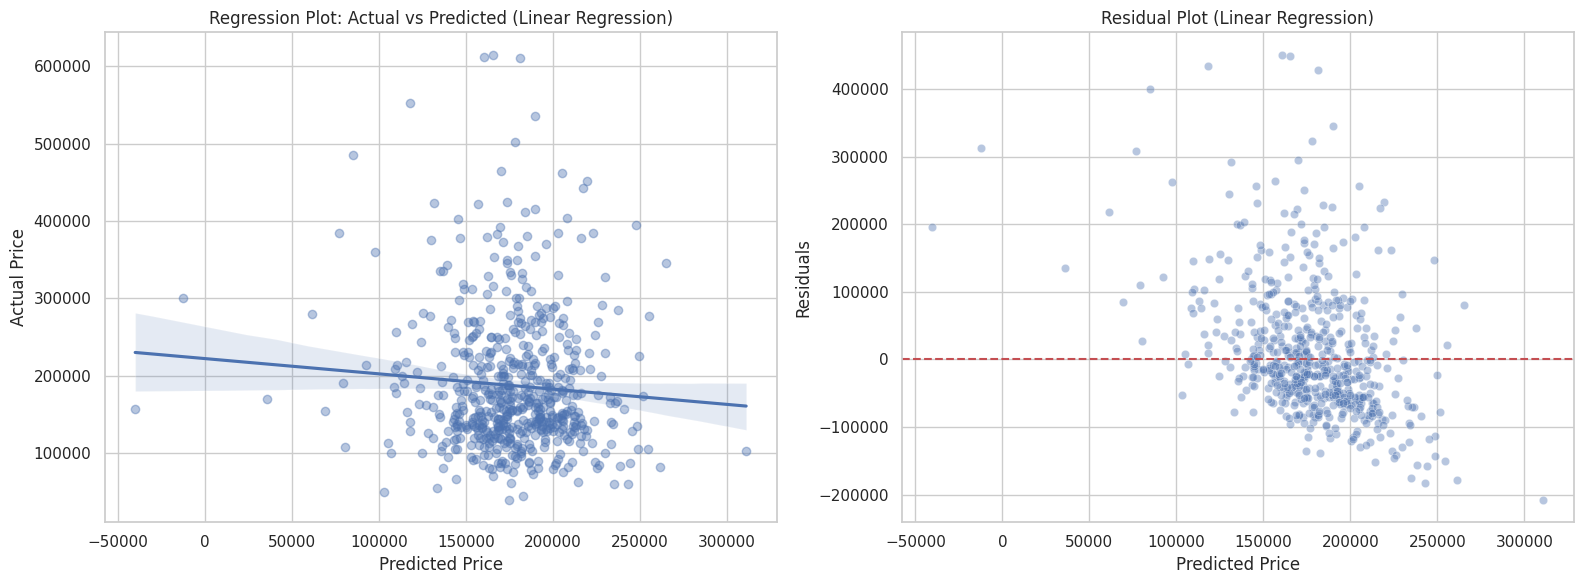

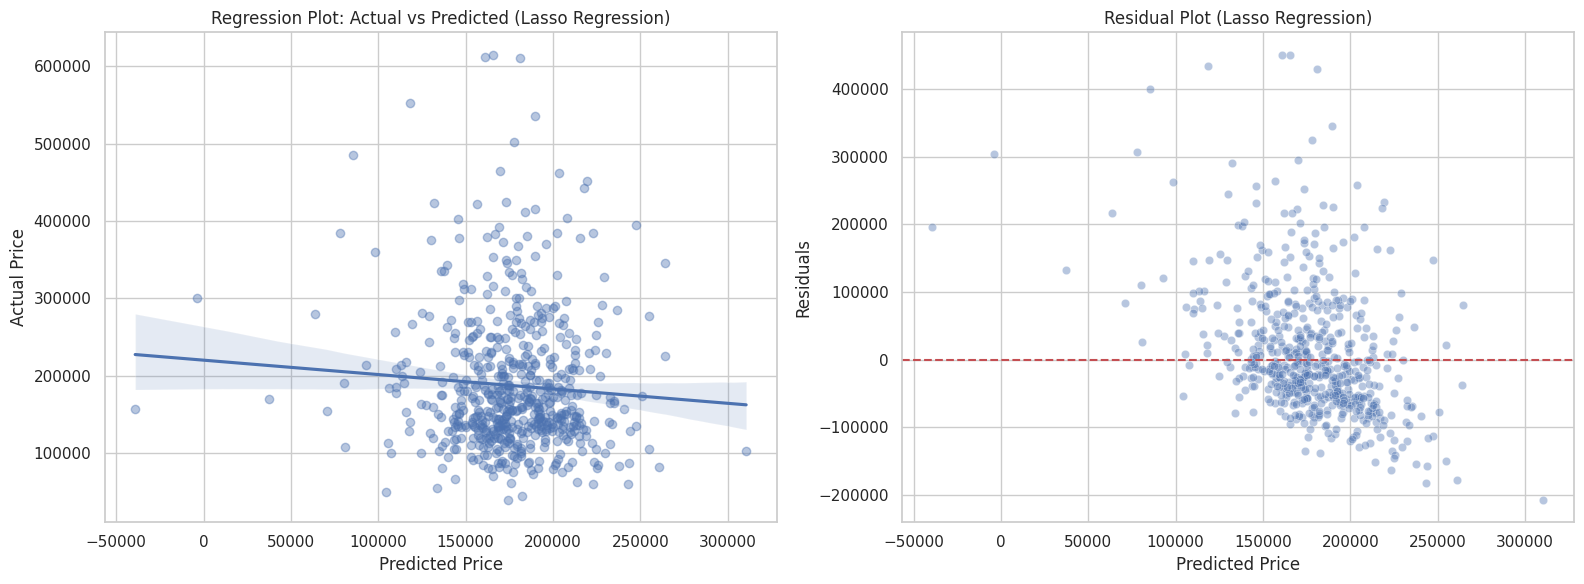

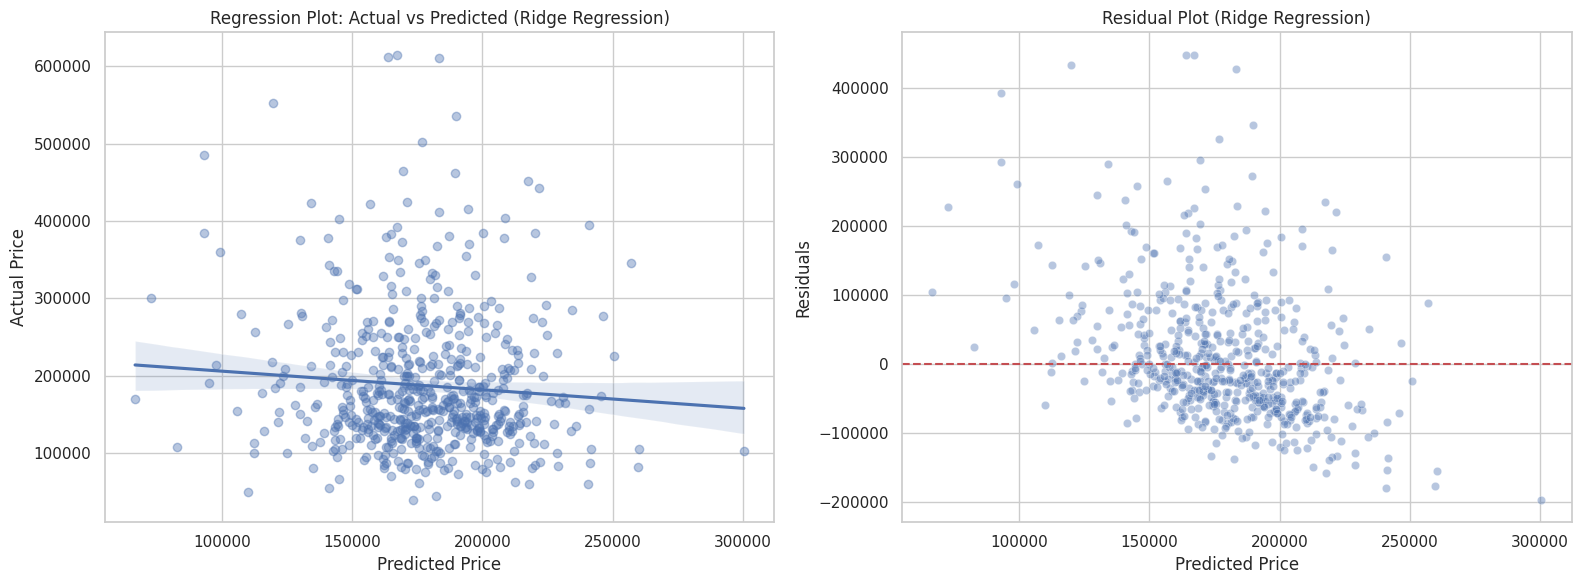

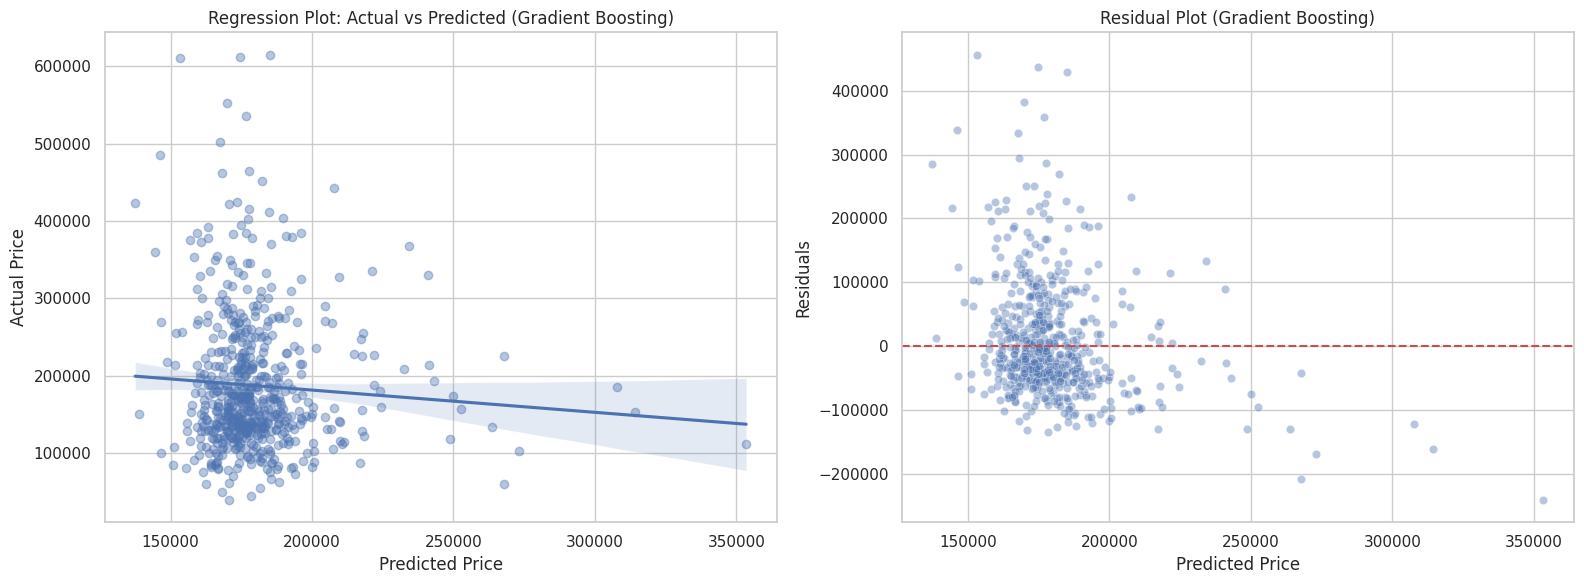

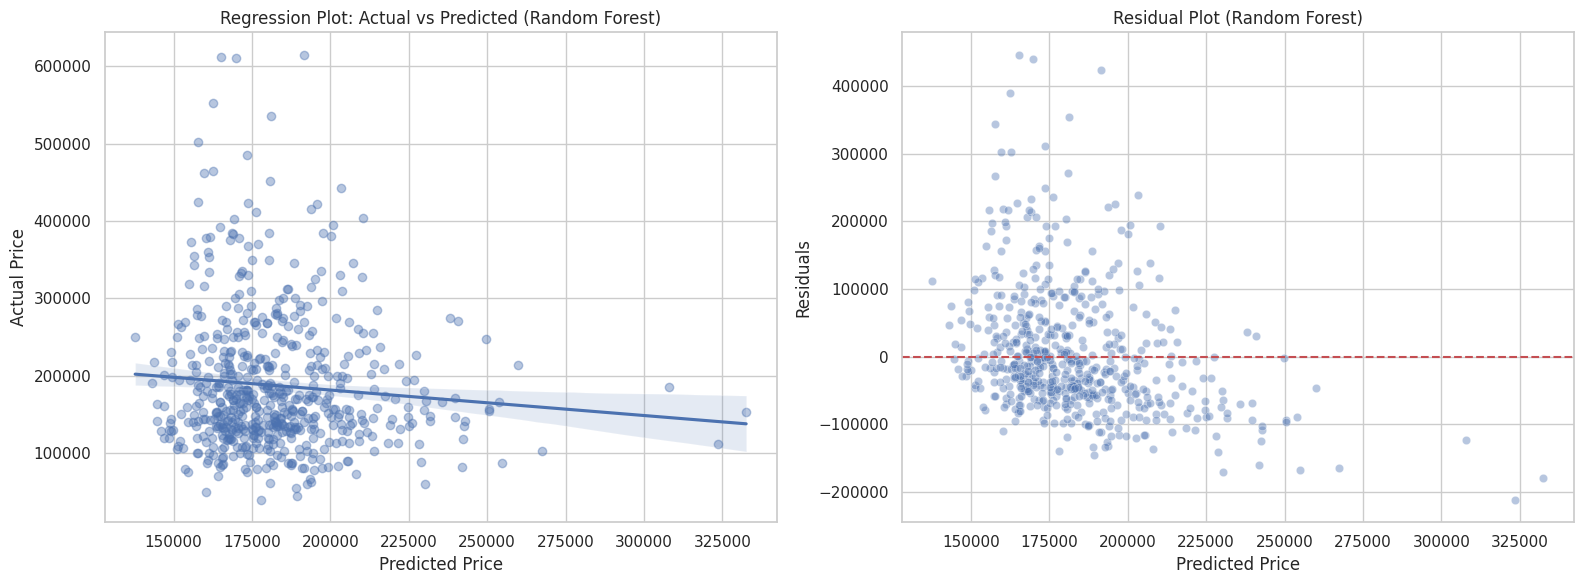

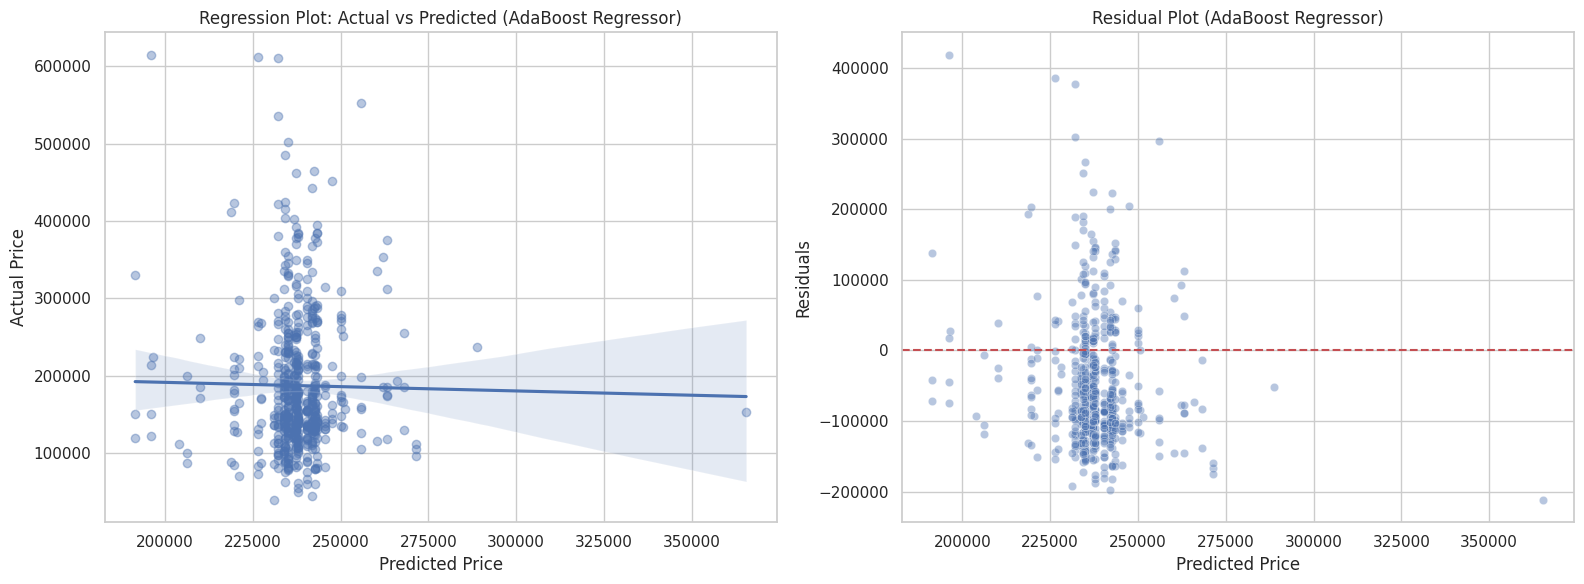

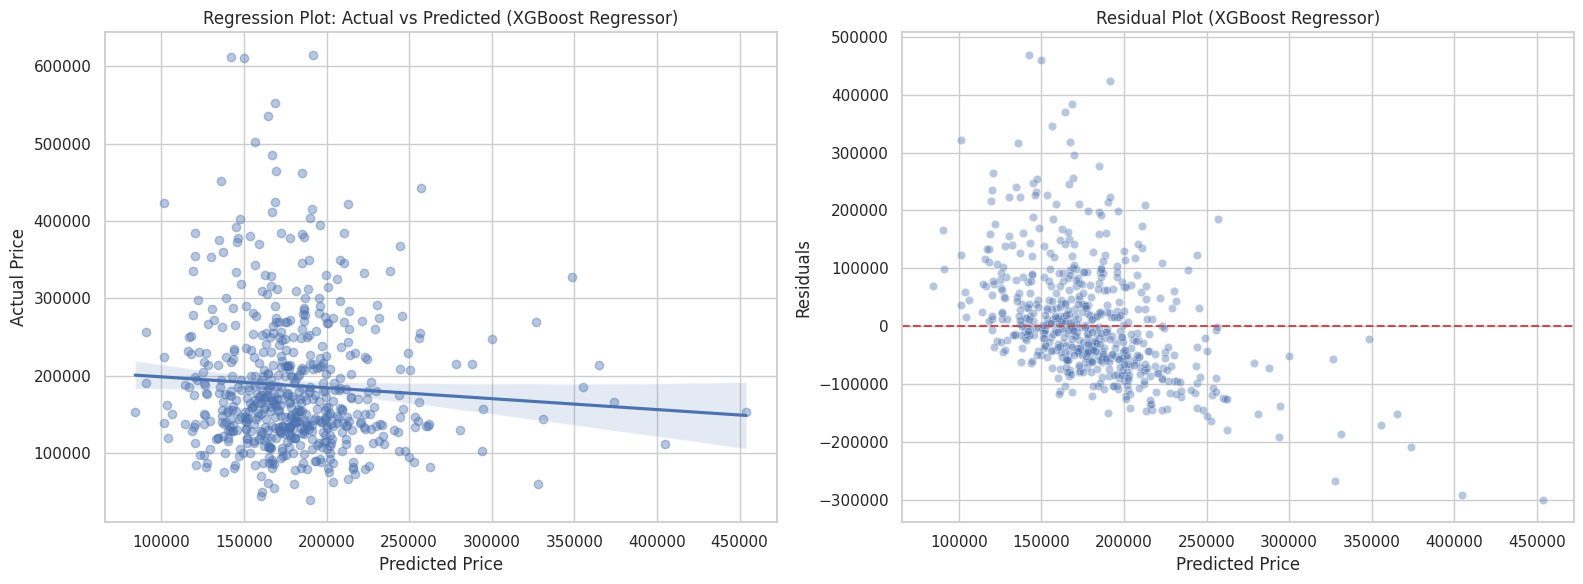

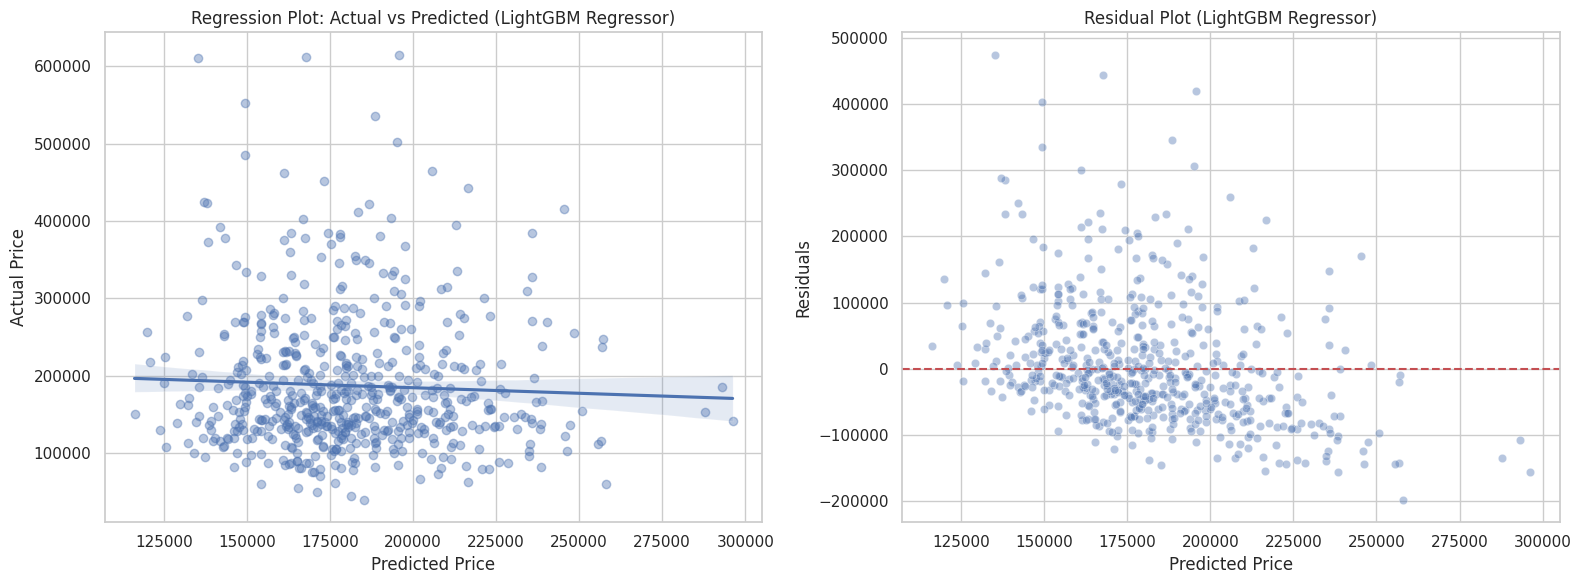

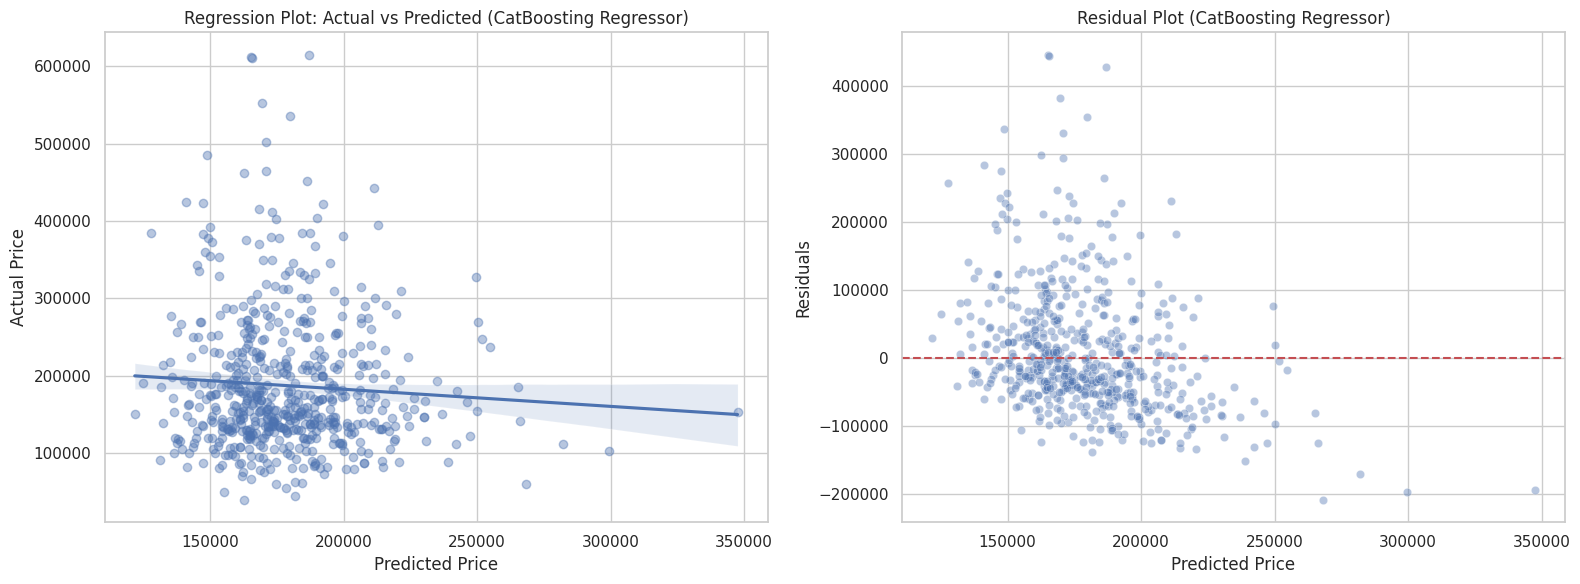

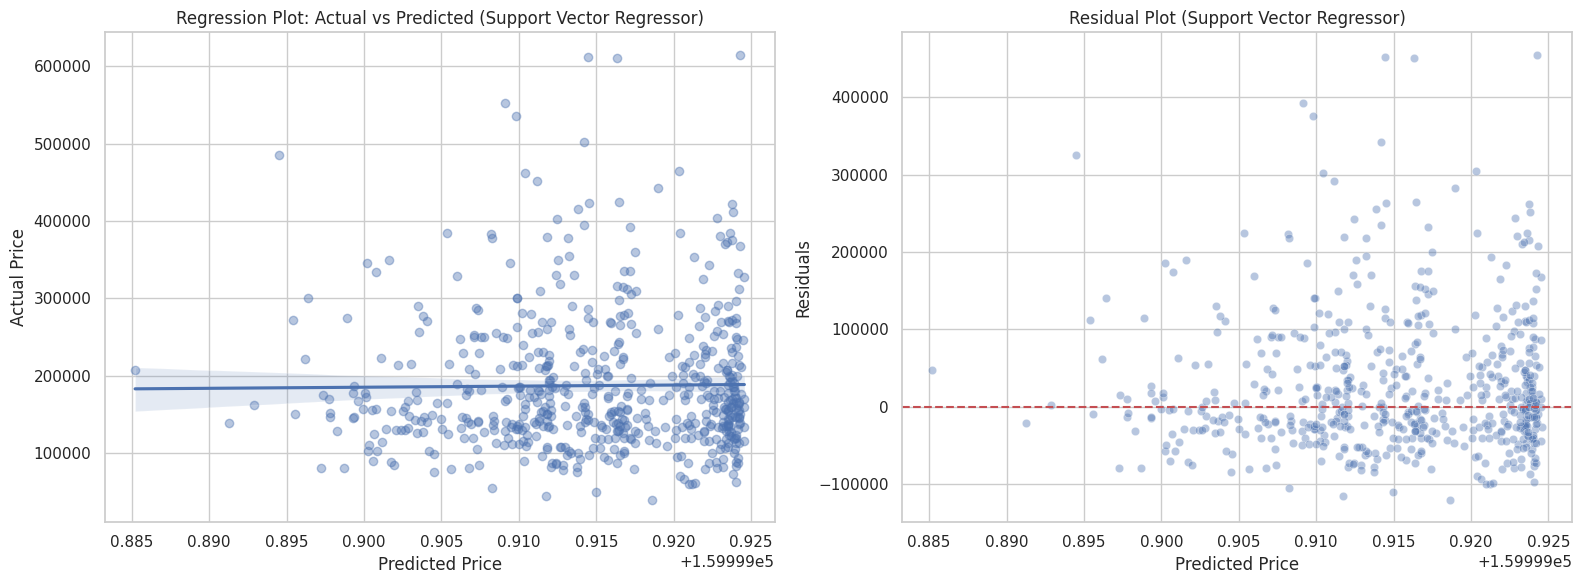

In [337]:
print('\nModel Performance Visualization')
for model_name, regressor in models.items():
    # Ensure the model is trained before predicting
    # The evaluate_regressor_models function already trains the models
    # So, we can directly predict using the models in the 'models' dictionary.
    y_pred = regressor.predict(X_test)

    plt.figure(figsize=(16, 6))

    # Regression Plot
    plt.subplot(1, 2, 1)
    sns.regplot(x=y_pred, y=y_test, scatter_kws={'alpha':0.4})
    plt.xlabel('Predicted Price')
    plt.ylabel('Actual Price')
    plt.title(f'Regression Plot: Actual vs Predicted ({model_name})')

    # Residual Plot
    plt.subplot(1, 2, 2)
    residuals = y_test - y_pred
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.4)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted Price')
    plt.ylabel('Residuals')
    plt.title(f'Residual Plot ({model_name})')

    plt.tight_layout()
    plt.show()

**Cross Validation**

In [339]:
from sklearn.model_selection import cross_validate

print("Cross-Validation Results:")
for model_name, regressor in models.items():
    scoring = {'mae': 'neg_mean_absolute_error', 'mse': 'neg_mean_squared_error', 'r2': 'r2'}
    cv_results = cross_validate(regressor, X, y, cv=5, scoring=scoring)
    print(f"\n{model_name}:")
    print(f"  Average MSE: {-cv_results['test_mse'].mean():.4f}")
    print(f"  Average MAE: {-cv_results['test_mae'].mean():.4f}")
    print(f"  Average RMSE: {np.sqrt(-cv_results['test_mse'].mean()):.4f}")
    print(f"  Average R2: {cv_results['test_r2'].mean():.4f}")

Cross-Validation Results:

Linear Regression:
  Average MSE: 7442539454.5624
  Average MAE: 63388.5076
  Average RMSE: 86270.1539
  Average R2: -0.1749

Lasso Regression:
  Average MSE: 7419751345.3327
  Average MAE: 63269.8702
  Average RMSE: 86137.9785
  Average R2: -0.1715

Ridge Regression:
  Average MSE: 7189980614.1124
  Average MAE: 62176.7875
  Average RMSE: 84793.7534
  Average R2: -0.1357

Gradient Boosting:
  Average MSE: 6809509663.3047
  Average MAE: 60169.7889
  Average RMSE: 82519.7532
  Average R2: -0.0741

Random Forest:
  Average MSE: 6808193073.7389
  Average MAE: 61217.9376
  Average RMSE: 82511.7754
  Average R2: -0.0758

AdaBoost Regressor:
  Average MSE: 9950121726.6109
  Average MAE: 85729.6699
  Average RMSE: 99750.2969
  Average R2: -0.5970

XGBoost Regressor:
  Average MSE: 7999100416.0000
  Average MAE: 65873.8234
  Average RMSE: 89437.6901
  Average R2: -0.2622
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info]

**Hyperparameter Tuning**

In [340]:
# default parameters
print("Default Parameters:")
for model_name, regressor in models.items():
    print(f'{model_name}')
    print(f'parameters: {regressor.get_params()}', end='\n\n')

Default Parameters:
Linear Regression
parameters: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

Lasso Regression
parameters: {'alpha': 1.0, 'copy_X': True, 'fit_intercept': True, 'max_iter': 1000, 'positive': False, 'precompute': False, 'random_state': None, 'selection': 'cyclic', 'tol': 0.0001, 'warm_start': False}

Ridge Regression
parameters: {'alpha': 1.0, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}

Gradient Boosting
parameters: {'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.1, 'loss': 'squared_error', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_st

In [347]:
# Define parameter grids for hyperparameter tuning
model_params = [
    ('Linear Regression', LinearRegression(), {
        'fit_intercept': [True, False]
    }),
    ('Lasso Regression', Lasso(), {
        'alpha': [0.1, 1.0, 10.0],
        'fit_intercept': [True, False]
    }),
    ('Ridge Regression', Ridge(), {
        'alpha': [0.1, 1.0, 10.0],
        'fit_intercept': [True, False]
    }),
    ('Random Forest', RandomForestRegressor(random_state=42), {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    }),
    ('GBM', GradientBoostingRegressor(random_state=42), {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0],
        'max_depth': [3, 5, 7]
    }),
    ('XGBoost', XGBRegressor(random_state=42), {
        'n_estimators': [200, 400],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    })
]

In [348]:
# Best parameters and scores initialization
best_model_name = None
best_model = None
best_score = float('-inf')
best_params = None

print("\nHyperparameter Tuning Results:")
for model_name, regressor, params in model_params:
    regressor_grid = GridSearchCV(regressor, params, cv=5, n_jobs=-1, verbose=1).fit(X, y)

    print(f"\nModel: {model_name}")
    print("Best Parameters:", regressor_grid.best_params_)
    print("Best Score:", regressor_grid.best_score_)
    print("\n")

    if regressor_grid.best_score_ > best_score:
        best_model_name = model_name
        best_model = regressor
        best_score = regressor_grid.best_score_
        best_params = regressor_grid.best_params_

print("\n\nFinal Inference")
print(f"Model: {best_model_name}")
print("Best Parameters:", best_params)
print("Best Score:", best_score)



Hyperparameter Tuning Results:
Fitting 5 folds for each of 2 candidates, totalling 10 fits

Model: Linear Regression
Best Parameters: {'fit_intercept': True}
Best Score: -0.1748854546377634


Fitting 5 folds for each of 6 candidates, totalling 30 fits

Model: Lasso Regression
Best Parameters: {'alpha': 10.0, 'fit_intercept': False}
Best Score: -0.14058783234061853


Fitting 5 folds for each of 6 candidates, totalling 30 fits

Model: Ridge Regression
Best Parameters: {'alpha': 10.0, 'fit_intercept': True}
Best Score: -0.08651403847299602


Fitting 5 folds for each of 27 candidates, totalling 135 fits

Model: Random Forest
Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: -0.037137444111544536


Fitting 5 folds for each of 54 candidates, totalling 270 fits

Model: GBM
Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 1.0}
Best Score: -0.012215805147943381


Fitting 5 folds for each of 36 candidates, totall

In [349]:
best_model

GradientBoostingRegressor(random_state=42)

In [352]:
# Function to find best model parameters
def best_params(model_params, best_model):
    for model_name, regressor, params in model_params:
        if best_model == regressor:
            return params
    return None

In [353]:
# Apply the function
best_model_params = best_params(model_params, best_model)

In [354]:
best_model_params

{'n_estimators': [50, 100, 200],
 'learning_rate': [0.01, 0.1, 0.2],
 'subsample': [0.8, 1.0],
 'max_depth': [3, 5, 7]}

In [355]:
# Final GridSearchCV with best model and its parameter grid
regressor_best_grid = GridSearchCV(best_model, best_model_params, cv=5, n_jobs=-1, verbose=1).fit(X, y)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


In [356]:
regressor_best_grid

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100, 200],
                         'subsample': [0.8, 1.0]},
             verbose=1)

In [358]:
final_model = GradientBoostingRegressor(
    **regressor_best_grid.best_params_
)

final_model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.01, n_estimators=50)

In [359]:
y_pred = final_model.predict(X_test)

In [361]:
y_pred

array([177844.83362967, 181689.70950943, 177844.83362967, 177416.96177909,
       177533.28013475, 177650.71596895, 181415.117318  , 181051.71536734,
       179311.40764568, 178368.16824614, 178806.94609573, 181217.10798829,
       191602.48573446, 179021.37602861, 180442.57388532, 179703.88311312,
       178838.61555736, 177650.71596895, 178593.95536849, 181966.22972711,
       180807.05517847, 178644.49789664, 177650.71596895, 178612.82843501,
       179541.62365962, 179084.09307752, 179556.06783455, 181330.84922328,
       183730.15019532, 178192.83276069, 177650.71596895, 181415.117318  ,
       179703.88311312, 180807.05517847, 179703.88311312, 177650.71596895,
       180421.33539031, 179674.57907998, 179568.02854634, 177844.83362967,
       180609.08579794, 177650.71596895, 179311.40764568, 177650.71596895,
       177650.71596895, 178562.28590686, 177844.83362967, 178368.16824614,
       180392.03135717, 178593.95536849, 177844.83362967, 178089.49381854,
       196841.43072495, 1

**Cross Validation**

In [362]:
print("Best Model Cross-Validation")

scoring = {
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
    'r2': 'r2'
}

cv_results_final = cross_validate(
    final_model,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

Best Model Cross-Validation


In [363]:
print("\nGradient Boosting:")

print(
    f"  Average MAE: "
    f"{-cv_results_final['test_mae'].mean():.4f}"
)

print(
    f"  Average MSE: "
    f"{-cv_results_final['test_mse'].mean():.4f}"
)

print(
    f"  Average RMSE: "
    f"{np.sqrt(-cv_results_final['test_mse'].mean()):.4f}"
)

print(
    f"  Average R2: "
    f"{cv_results_final['test_r2'].mean():.4f}"
)


Gradient Boosting:
  Average MAE: 56543.9285
  Average MSE: 6034580382.0091
  Average RMSE: 77682.5616
  Average R2: -0.0036


**Feature evaluation on `X_test`**

In [364]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_test_pred = final_model.predict(X_test)

mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)

print("Final Test Performance")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

Final Test Performance
MAE:  63843.6059
MSE:  7874927942.2511
RMSE: 88740.7907
R²:   -0.0108


**Feature Importance**

In [365]:
def visualize_importance(model, features, start=0, num=20):

    feature_imp = pd.DataFrame({
        'Feature': features.columns,
        'Importance': model.feature_importances_
    })

    feature_imp = feature_imp.sort_values(
        by='Importance',
        ascending=False
    )

    selected = feature_imp.iloc[start:num]

    display(selected)

    plt.figure(figsize=(12, 8))

    sns.barplot(
        x='Importance',
        y='Feature',
        data=selected
    )

    plt.title('Feature Importance')
    plt.tight_layout()
    plt.show()

,Feature,Importance
222,Heating_Floor,0.139210
254,Sale_Type_ConLD,0.069472
20,Kitchen_AbvGr,0.067195
9,Total_Bsmt_SF,0.053576
35,TotalSF,0.052839
23,Garage_Yr_Blt,0.041628
25,Garage_Area,0.041273
181,Exterior_2nd_CmentBd,0.040481
196,BsmtFin_Type_2_ALQ,0.038676
141,Neighborhood_CollgCr,0.036024


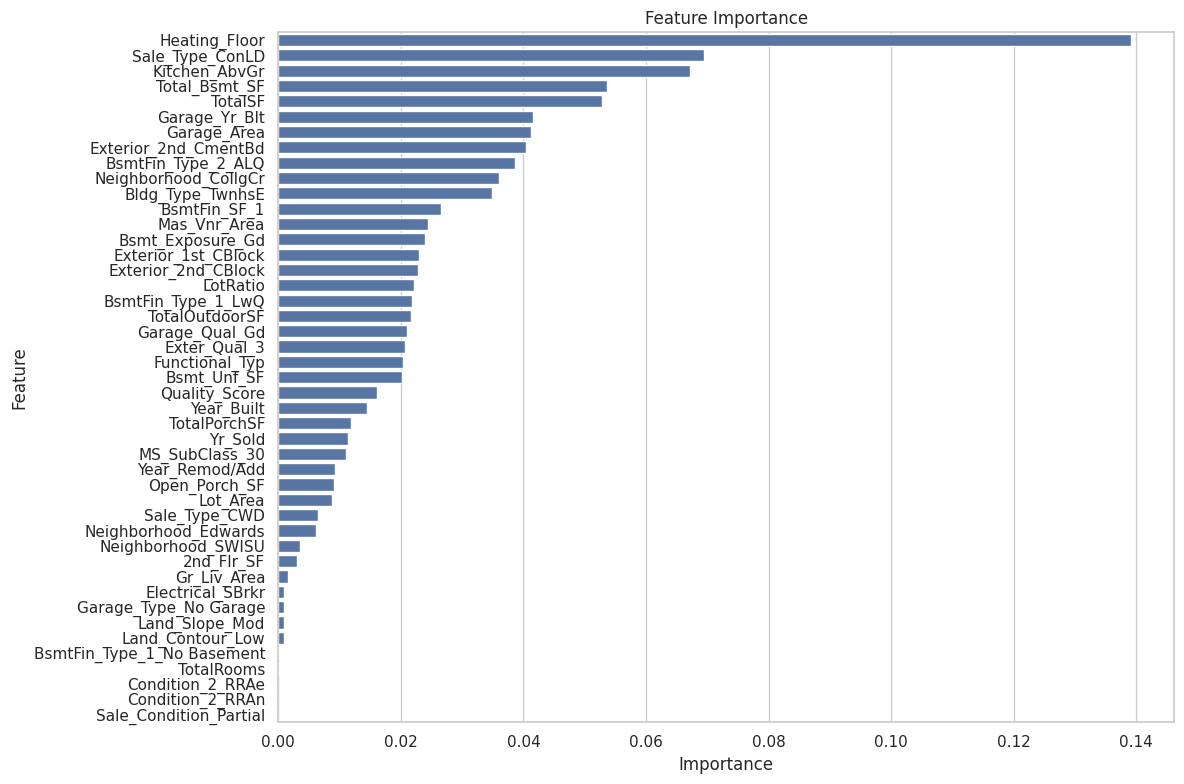

In [366]:
visualize_importance(
    final_model,
    X_train,
    start=0,
    num=45
)

In [368]:
predictions = final_model.predict(X_test)

In [369]:
predictions

array([177844.83362967, 181689.70950943, 177844.83362967, 177416.96177909,
       177533.28013475, 177650.71596895, 181415.117318  , 181051.71536734,
       179311.40764568, 178368.16824614, 178806.94609573, 181217.10798829,
       191602.48573446, 179021.37602861, 180442.57388532, 179703.88311312,
       178838.61555736, 177650.71596895, 178593.95536849, 181966.22972711,
       180807.05517847, 178644.49789664, 177650.71596895, 178612.82843501,
       179541.62365962, 179084.09307752, 179556.06783455, 181330.84922328,
       183730.15019532, 178192.83276069, 177650.71596895, 181415.117318  ,
       179703.88311312, 180807.05517847, 179703.88311312, 177650.71596895,
       180421.33539031, 179674.57907998, 179568.02854634, 177844.83362967,
       180609.08579794, 177650.71596895, 179311.40764568, 177650.71596895,
       177650.71596895, 178562.28590686, 177844.83362967, 178368.16824614,
       180392.03135717, 178593.95536849, 177844.83362967, 178089.49381854,
       196841.43072495, 1

In [370]:
test_sample = X_test.iloc[0].values.reshape(1, -1)
prediction = final_model.predict(test_sample)
print(prediction)

[177844.83362967]


In [371]:
predict_df = X_test.copy()

##13. Saving model with Pickle

In [373]:
import pickle

with open('ames_ml_model.pkl', 'wb') as file:
    pickle.dump(final_model, file)

print("Model saved to ames_ml_model.pkl")

Model saved to ames_ml_model.pkl


**Loading model and predicting using it**

In [374]:
# Load model from pickle file
with open('ames_ml_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

result = loaded_model.score(X_test, y_test)
print(result)

print('Predicted SalePrice is : ', loaded_model.predict(predict_df))

-0.01084229235907852
Predicted SalePrice is :  [177844.83362967 181689.70950943 177844.83362967 177416.96177909
 177533.28013475 177650.71596895 181415.117318   181051.71536734
 179311.40764568 178368.16824614 178806.94609573 181217.10798829
 191602.48573446 179021.37602861 180442.57388532 179703.88311312
 178838.61555736 177650.71596895 178593.95536849 181966.22972711
 180807.05517847 178644.49789664 177650.71596895 178612.82843501
 179541.62365962 179084.09307752 179556.06783455 181330.84922328
 183730.15019532 178192.83276069 177650.71596895 181415.117318
 179703.88311312 180807.05517847 179703.88311312 177650.71596895
 180421.33539031 179674.57907998 179568.02854634 177844.83362967
 180609.08579794 177650.71596895 179311.40764568 177650.71596895
 177650.71596895 178562.28590686 177844.83362967 178368.16824614
 180392.03135717 178593.95536849 177844.83362967 178089.49381854
 196841.43072495 180421.33539031 178562.28590686 178562.28590686
 178386.95042141 176874.84498735 179361.95017